In [1]:
import pyomo.environ as pyo
import mpisppy.utils.sputils as sputils
from mpisppy.opt.ef import ExtensiveForm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Configuração para que os gráficos apareçam inline no Jupyter
%matplotlib inline

[    0.00] Initializing mpi-sppy


In [2]:
# --- Horizonte de Tempo ---
N = 96
TIME_HORIZON = np.arange(N)
INTERVALO_HORAS = 0.25

# --- Capacidades e Limites de Potência (W) ---
LOAD_MAX_W = 50e6               # Carga máxima
GEN_MAX_W = 150e6               # Geração Solar/Eólica máxima
MAX_ELECTROLYZER_POWER_W = 52.5e6 
MAX_THERMAL_ELEC_POWER_W = 11e6
MAX_GRID_TRADE_MW = 150         # Limite de interconexão com a rede
MAX_GRID_RAMP_MW_PER_INTERVAL = 5 # Limite de variação da rede por 15 min

# --- Armazenamento (BESS e Tanques) ---
ELEC_STORAGE_SIZE_WH = 20e6     # Capacidade BESS: 20 MWh
ELEC_STORAGE_RATE = 0.25        # Taxa de carga/descarga
elec_min_soc_wh = ELEC_STORAGE_SIZE_WH * 0.05
elec_max_soc_wh = ELEC_STORAGE_SIZE_WH * 0.95

H2_STORAGE_SIZE_KG = 22.8e3     # Capacidade Tanque H2
H2_STORAGE_RATE = 0.3
AMMONIA_STORAGE_SIZE_KG = 50000.0
AMMONIA_STORAGE_RATE = 0.1

# --- Ponderações Técnicas (Eficiências e Conversões) ---
TX_ELEC_TO_H2_KWH_KG = 55.62    # Consumo específico eletrolisador
EFF_H2_TO_ELEC = 0.348          # Eficiência Turbina SGT-400
EFF_STORAGE = 0.90              # Eficiência (BESS/H2)
TX_H2_TO_AMMONIA_KG_PER_KG = 0.178
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 400

# --- Ponderações Financeiras ---
SLACK_PENALTY = 1e9             # Penalidade por descumprimento de carga


In [3]:
MAX_ELECTROLYZER_POWER_W = 52.5e6
MIN_ELECTROLYZER_POWER_W = 0.1 * MAX_ELECTROLYZER_POWER_W
MAX_THERMAL_ELEC_POWER_W = 11e6
MIN_UPTIME_INTERVALS = 4
MAX_GRID_TRADE_MW = 50
MIN_DOWNTIME_INTERVALS = 2
SLACK_PENALTY = 1e9
H2_PRECO_COMPRA_EXTERNA = 50.0
CUSTO_STARTUP_TERMICA = 50.0
TX_H2_TO_AMMONIA_KG_PER_KG = 0.178
AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG = 400
AMMONIA_PLANT_CAPACITY_KG_PER_INTERVAL = 1500 * INTERVALO_HORAS
AMMONIA_STORAGE_SIZE_KG = 50000.0
AMMONIA_STORAGE_RATE = 0.1
elec_min_soc_wh = ELEC_STORAGE_SIZE_WH * 0.05
elec_max_soc_wh = ELEC_STORAGE_SIZE_WH * 0.95
# max_charge_power_w e max_discharge_power_w são calculados com base nos novos ELEC_STORAGE_SIZE_WH e ELEC_STORAGE_RATE
max_charge_power_w = ELEC_STORAGE_SIZE_WH * ELEC_STORAGE_RATE
max_discharge_power_w = ELEC_STORAGE_SIZE_WH * ELEC_STORAGE_RATE
h2_min_soc_kg = H2_STORAGE_SIZE_KG * 0.00
h2_max_soc_kg = H2_STORAGE_SIZE_KG * 1.00
max_h2_charge_rate_kg = H2_STORAGE_SIZE_KG * H2_STORAGE_RATE * INTERVALO_HORAS
max_h2_discharge_rate_kg = H2_STORAGE_SIZE_KG * H2_STORAGE_RATE * INTERVALO_HORAS
ammonia_min_soc_kg = AMMONIA_STORAGE_SIZE_KG * 0.0
ammonia_max_soc_kg = AMMONIA_STORAGE_SIZE_KG * 1.0

#Definir limites e quantidade para o processo de transformação H2V -> Amonia

max_ammonia_charge_rate_kg = AMMONIA_STORAGE_SIZE_KG * AMMONIA_STORAGE_RATE * INTERVALO_HORAS
max_ammonia_discharge_rate_kg = AMMONIA_STORAGE_SIZE_KG * AMMONIA_STORAGE_RATE * INTERVALO_HORAS

In [4]:
def carregar_pld_12m(caminho_arquivo, sheet=0):
    """
    Carrega e processa o arquivo de PLD, renomeando colunas e tratando tipos de dados.
    """
    if not os.path.exists(caminho_arquivo):
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_arquivo}")
    df = pd.read_excel(caminho_arquivo, sheet_name=sheet, header=0)
    df.columns = df.columns.map(lambda c: str(c).strip().lower())
    if not {"hour", "spotpricebrl"}.issubset(df.columns):
        raise ValueError(f"Esperava colunas {{'hour', 'spotpricebrl'}}, mas encontrei {set(df.columns)}.")
    df["hour"] = pd.to_datetime(df["hour"], errors="coerce")
    df["spotpricebrl"] = pd.to_numeric(df["spotpricebrl"], errors="coerce")
    if df["hour"].isna().any() or df["spotpricebrl"].isna().any():
        raise ValueError("Valores nulos ou inválidos encontrados no arquivo de PLD após a conversão.")
    df = df.rename(columns={"hour": "data", "spotpricebrl": "pld"})
    return df.sort_values("data").reset_index(drop=True)

def gerar_perfis_realistas(N, intervalo_horas, pot_solar_max_w, pot_eolica_max_w, pot_carga_max_w):
    """
    Gera perfis sintéticos de solar, eólica e carga.
    Esta função será usada apenas para a carga, a menos que dados reais de carga sejam fornecidos.
    """
    horas = np.arange(0, 24, intervalo_horas)
    perfil_solar_unitario = np.maximum(0, np.sin(np.pi * (horas - 6) / 12))**1.5
    solar_gen_w = perfil_solar_unitario * pot_solar_max_w
    perfil_eolico_unitario = (0.5 + 0.2 * np.sin(np.pi * horas / 6) + 0.3 * np.cos(np.pi * horas / 12 + np.pi/4) + 0.1 * np.random.rand(N))
    perfil_eolico_unitario = np.clip(perfil_eolico_unitario, 0, 1)
    eolica_gen_w = perfil_eolico_unitario * pot_eolica_max_w
    perfil_carga_unitario = (0.55 - 0.25 * np.cos(2 * np.pi * (horas - 4) / 24) + 0.4 * np.exp(-0.5 * ((horas - 15) / 3.5)**2))
    carga_w = perfil_carga_unitario * pot_carga_max_w
    return solar_gen_w.tolist(), eolica_gen_w.tolist(), carga_w.tolist()

def carregar_geracao_data(caminho_arquivo, N_intervals, unit_conversion_factor=1e6, sheet_name=0):

    if not os.path.exists(caminho_arquivo):
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_arquivo}")

    df = pd.read_excel(caminho_arquivo, sheet_name=sheet_name, header=None) # Lê sem cabeçalho inicialmente

    generation_data = []
 
    if df.shape[0] == N_intervals: # Assume que os dados começam na linha 0
        generation_data = df.iloc[:, 1].values # Assume que a geração está na segunda coluna (índice 1)
    elif df.shape[0] == N_intervals + 1: # Assume que há um cabeçalho na linha 0, dados começam na linha 1
        generation_data = df.iloc[1:, 1].values # Assume que a geração está na segunda coluna (índice 1)
    else:
        raise ValueError(f"O arquivo {caminho_arquivo} não contém {N_intervals} ou {N_intervals+1} linhas de dados esperadas para 96 intervalos. Encontradas {df.shape[0]} linhas.")

    # Converte para numérico, tratando valores não numéricos (NaN) como 0.0
    generation_profile = [float(x) if pd.notna(x) else 0.0 for x in generation_data]

    if len(generation_profile) != N_intervals:
        raise ValueError(f"O perfil de geração lido do arquivo {caminho_arquivo} tem {len(generation_profile)} pontos, mas {N_intervals} eram esperados.")

    # Aplica o fator de conversão de unidade (MW para W)
    converted_profile = [val * unit_conversion_factor for val in generation_profile]

    return converted_profile


def load_and_process_scenario_data(pld_data, solar_mean_profile, wind_mean_profile, fixed_h2_price=25.0, fixed_ammonia_price=4.27):
    """
    Carrega e processa os dados para os diferentes cenários de otimização.
    A geração solar e eólica utiliza sempre o perfil de média agregada.
    A variabilidade dos cenários é definida pelos dados de PLD.
    """
    print(f"--- Construindo perfis: Preço H₂ (Venda) = R$ {fixed_h2_price:.2f}/kg | Preço Amônia (Venda) = R$ {fixed_ammonia_price:.2f}/kg ---")
    
    # A carga (load_w) ainda será gerada sinteticamente, pois não há dados de carga real fornecidos.
    _, _, load_w = gerar_perfis_realistas(N, INTERVALO_HORAS, GEN_MAX_W, GEN_MAX_W, LOAD_MAX_W)

    profiles = {
        'optimal': {
            'wind_gen_w': wind_mean_profile,  # Cenário 'optimal' usa geração eólica média agregada
            'solar_gen_w': solar_mean_profile  # Cenário 'optimal' usa geração solar média agregada
        },
        'good': {
            'wind_gen_w': wind_mean_profile, # Cenário 'good' usa geração eólica média agregada
            'solar_gen_w': solar_mean_profile # Cenário 'good' usa geração solar média agregada
        },
        'bad': {
            'wind_gen_w': wind_mean_profile,  # Cenário 'bad' usa geração eólica média agregada
            'solar_gen_w': solar_mean_profile  # Cenário 'bad' usa geração solar média agregada
        }
    }
    
    # Atribui os preços de PLD aos cenários
    profiles['optimal']['spot_prices_mwh'] = pld_data['low']  # PLD baixo para cenário 'optimal' (custo de compra menor)
    profiles['good']['spot_prices_mwh'] = pld_data['mean']   # PLD médio para cenário 'good'
    profiles['bad']['spot_prices_mwh'] = pld_data['high']    # PLD alto para cenário 'bad' (custo de compra maior)

    h2_price_per_kg_venda = [fixed_h2_price] * N
    ammonia_price_per_kg_venda = [fixed_ammonia_price] * N
    
    for p_name in profiles:
        profiles[p_name]['load_w'] = load_w # A carga é a mesma para todos os cenários por enquanto
        profiles[p_name]['h2_price_venda'] = h2_price_per_kg_venda
        profiles[p_name]['ammonia_price_venda'] = ammonia_price_per_kg_venda
    return profiles

In [5]:
def build_model(scenario_profiles):
    model = pyo.ConcreteModel()
    model.time = pyo.Set(initialize=TIME_HORIZON)
    
    # --- Parâmetros do Modelo ---
    model.p_solar = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['solar_gen_w'])})
    model.p_wind = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['wind_gen_w'])})
    model.p_load = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['load_w'])})
    model.price = pyo.Param(model.time, initialize={t: p/1e6 for t, p in enumerate(scenario_profiles['spot_prices_mwh'])})
    model.h2_price_venda = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['h2_price_venda'])})
    model.ammonia_price_venda = pyo.Param(model.time, initialize={t: v for t, v in enumerate(scenario_profiles['ammonia_price_venda'])})

    # --- Variáveis de Decisão (Primeiro Estágio) ---
    model.X = pyo.Var(["ELEC_INITIAL_SOC", "H2_INITIAL_SOC", "AMMONIA_INITIAL_SOC"], within=pyo.NonNegativeReals)
    
    # --- Variáveis de Operação (Segundo Estágio) ---
    model.GRID_BUY_POWER = pyo.Var(model.time, bounds=(0, MAX_GRID_TRADE_MW * 1e6))
    model.GRID_SELL_POWER = pyo.Var(model.time, bounds=(0, MAX_GRID_TRADE_MW * 1e6))
    model.BESS_SOC = pyo.Var(model.time, bounds=(elec_min_soc_wh, elec_max_soc_wh))
    model.H2_STORAGE_SOC = pyo.Var(model.time, bounds=(0, H2_STORAGE_SIZE_KG))
    model.AMMONIA_STORAGE_SOC = pyo.Var(model.time, bounds=(0, AMMONIA_STORAGE_SIZE_KG))
    model.H2_TO_MARKET_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.AMMONIA_TO_MARKET_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.ELECTRICITY_SLACK_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    
    # Variáveis auxiliares de fluxo
    model.BESS_CHARGE_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.BESS_DISCHARGE_POWER = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.ELECTROLYZER_ELEC_CONSUMPTION = pyo.Var(model.time, bounds=(0, MAX_ELECTROLYZER_POWER_W))
    model.AMMONIA_PRODUCED_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.H2_PRODUCED = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.H2_TO_AMMONIA_PLANT_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)
    model.THERMAL_ELEC_GENERATION = pyo.Var(model.time, bounds=(0, MAX_THERMAL_ELEC_POWER_W))
    model.H2_TO_THERMAL_MASS = pyo.Var(model.time, within=pyo.NonNegativeReals)

    # --- FUNÇÃO OBJETIVO: MAXIMIZAÇÃO DE LUCRO ---
    def objective_rule(m):
        receita = sum(m.h2_price_venda[t] * m.H2_TO_MARKET_MASS[t] for t in m.time) + \
                  sum(m.ammonia_price_venda[t] * m.AMMONIA_TO_MARKET_MASS[t] for t in m.time) + \
                  sum(m.price[t] * m.GRID_SELL_POWER[t] * INTERVALO_HORAS for t in m.time)
        custo = sum(m.price[t] * m.GRID_BUY_POWER[t] * INTERVALO_HORAS for t in m.time) + \
                sum(m.ELECTRICITY_SLACK_POWER[t] * SLACK_PENALTY for t in m.time)
        return receita - custo
    model.OBJ = pyo.Objective(rule=objective_rule, sense=pyo.maximize)

    # --- RESTRIÇÕES ---
    model.CONSTR = pyo.ConstraintList()
    for t in model.time:
        # 1. Balanço Elétrico
        cons_ammonia_w = model.AMMONIA_PRODUCED_MASS[t] * AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG / INTERVALO_HORAS
        model.CONSTR.add(model.p_solar[t] + model.p_wind[t] + model.BESS_DISCHARGE_POWER[t] + \
                         model.THERMAL_ELEC_GENERATION[t] + model.GRID_BUY_POWER[t] + model.ELECTRICITY_SLACK_POWER[t] == \
                         model.p_load[t] + model.BESS_CHARGE_POWER[t] + model.ELECTROLYZER_ELEC_CONSUMPTION[t] + \
                         model.GRID_SELL_POWER[t] + cons_ammonia_w)
        
        # 2. Conversão H2 (Ponderação 55.62 kWh/kg)
        model.CONSTR.add(model.H2_PRODUCED[t] == (model.ELECTROLYZER_ELEC_CONSUMPTION[t] * INTERVALO_HORAS) / (TX_ELEC_TO_H2_KWH_KG * 1000))
        
        # 3. Dinâmica de Estoque (SOC)
        soc_ant_elec = model.X["ELEC_INITIAL_SOC"] if t == 0 else model.BESS_SOC[t-1]
        model.CONSTR.add(model.BESS_SOC[t] == soc_ant_elec + (model.BESS_CHARGE_POWER[t] * 0.9 - model.BESS_DISCHARGE_POWER[t] / 0.9) * INTERVALO_HORAS)

        soc_ant_h2 = model.X["H2_INITIAL_SOC"] if t == 0 else model.H2_STORAGE_SOC[t-1]
        model.CONSTR.add(model.H2_STORAGE_SOC[t] == soc_ant_h2 + model.H2_PRODUCED[t] - \
                         model.H2_TO_MARKET_MASS[t] - model.H2_TO_THERMAL_MASS[t] - model.H2_TO_AMMONIA_PLANT_MASS[t])

        soc_ant_nh3 = model.X["AMMONIA_INITIAL_SOC"] if t == 0 else model.AMMONIA_STORAGE_SOC[t-1]
        model.CONSTR.add(model.AMMONIA_STORAGE_SOC[t] == soc_ant_nh3 + model.AMMONIA_PRODUCED_MASS[t] - model.AMMONIA_TO_MARKET_MASS[t])
        model.CONSTR.add(model.AMMONIA_PRODUCED_MASS[t] == model.H2_TO_AMMONIA_PLANT_MASS[t] / TX_H2_TO_AMMONIA_KG_PER_KG)

    # 4. Condições de Contorno Finais (Sustentabilidade SOC_f >= SOC_i)
    model.CONSTR.add(model.BESS_SOC[N-1] >= model.X["ELEC_INITIAL_SOC"])
    model.CONSTR.add(model.H2_STORAGE_SOC[N-1] >= model.X["H2_INITIAL_SOC"])
    model.CONSTR.add(model.AMMONIA_STORAGE_SOC[N-1] >= model.X["AMMONIA_INITIAL_SOC"])

    return model

In [6]:
def scenario_creator(scenario_name, all_profiles, **kwargs):
    if scenario_name not in all_profiles:
        raise ValueError(f"Perfil para o cenário '{scenario_name}' não encontrado.")
    
    scenario_data = all_profiles[scenario_name]
    model = build_model(scenario_data)
    
    # Vincula as variáveis de primeiro estágio (SOC Inicial) entre todos os cenários
    sputils.attach_root_node(model, 0.0, list(model.X.values()))
    model._mpisppy_probability = 1.0 / len(all_profiles)
    
    return model

In [7]:
def plot_scenario_results(s_block, s_name, initial_soc_dict, fixed_h2_price, fixed_ammonia_price):
  #  print(f"\n--- Gerando gráficos para o Cenário: {s_name.upper()} ---")
    
    # Extração de resultados
    res_solar = np.array([pyo.value(s_block.p_solar[t]) for t in TIME_HORIZON]) / 1e6
    res_wind = np.array([pyo.value(s_block.p_wind[t]) for t in TIME_HORIZON]) / 1e6
    res_load = np.array([pyo.value(s_block.p_load[t]) for t in TIME_HORIZON]) / 1e6
    res_elec_price = np.array([pyo.value(s_block.price[t]) for t in TIME_HORIZON]) * 1e6
    res_grid_buy = np.array([pyo.value(s_block.GRID_BUY_POWER[t]) for t in TIME_HORIZON]) / 1e6
    res_grid_sell = np.array([pyo.value(s_block.GRID_SELL_POWER[t]) for t in TIME_HORIZON]) / 1e6
    res_bess_charge = np.array([pyo.value(s_block.BESS_CHARGE_POWER[t]) for t in TIME_HORIZON]) / 1e6
    res_bess_discharge = np.array([pyo.value(s_block.BESS_DISCHARGE_POWER[t]) for t in TIME_HORIZON]) / 1e6
    res_bess_soc = np.array([pyo.value(s_block.BESS_SOC[t]) for t in TIME_HORIZON]) / 1e6
    res_electrolyzer_consumption = np.array([pyo.value(s_block.ELECTROLYZER_ELEC_CONSUMPTION[t]) for t in TIME_HORIZON]) / 1e6
    res_thermal_generation = np.array([pyo.value(s_block.THERMAL_ELEC_GENERATION[t]) for t in TIME_HORIZON]) / 1e6
    res_h2_produced = np.array([pyo.value(s_block.H2_PRODUCED[t]) for t in TIME_HORIZON])
    res_h2_soc = np.array([pyo.value(s_block.H2_STORAGE_SOC[t]) for t in TIME_HORIZON])
    res_h2_to_market = np.array([pyo.value(s_block.H2_TO_MARKET_MASS[t]) for t in TIME_HORIZON])
    res_h2_to_thermal = np.array([pyo.value(s_block.H2_TO_THERMAL_MASS[t]) for t in TIME_HORIZON])
    res_h2_to_ammonia = np.array([pyo.value(s_block.H2_TO_AMMONIA_PLANT_MASS[t]) for t in TIME_HORIZON])
    res_ammonia_produced = np.array([pyo.value(s_block.AMMONIA_PRODUCED_MASS[t]) for t in TIME_HORIZON])
    res_ammonia_soc = np.array([pyo.value(s_block.AMMONIA_STORAGE_SOC[t]) for t in TIME_HORIZON])
    res_ammonia_to_market = np.array([pyo.value(s_block.AMMONIA_TO_MARKET_MASS[t]) for t in TIME_HORIZON])
    
    # NOVO: Calcular consumo elétrico da planta de amônia (em MW)
    res_ammonia_plant_elec_consumption_mw = np.array([
        pyo.value(s_block.AMMONIA_PRODUCED_MASS[t]) * AMMONIA_PLANT_ELEC_CONSUMPTION_WH_PER_KG / INTERVALO_HORAS
        for t in TIME_HORIZON
    ]) / 1e6 # Converter para MW

    passos_por_hora = int(1 / INTERVALO_HORAS)
    x_ticks = np.arange(0, N + 1, passos_por_hora * 4)
    x_labels = [f"{int(t/passos_por_hora):02d}:00" for t in x_ticks]
    
    filename_base = f"resultados_h2_{fixed_h2_price:.2f}_amonia_{fixed_ammonia_price:.2f}_pld_{s_name}"

    # --- Gráfico 1: Elétrico ---
    fig1, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 16), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1.5]})
    fig1.suptitle(f'Despacho Elétrico | Cenário PLD: {s_name.upper()}', fontsize=16)

    # AX1 - Balanço Geral de Potência
    ax1.set_title('Balanço Geral de Potência')
    ax1.plot(TIME_HORIZON, res_solar, label='Solar', color='gold')
    ax1.plot(TIME_HORIZON, res_wind, label='Eólica', color='deepskyblue')
    ax1.plot(TIME_HORIZON, res_thermal_generation, label='Térmica H₂', color='darkviolet')
    ax1.plot(TIME_HORIZON, res_grid_buy, label='Rede (Compra)', color='darkorange')
    ax1.plot(TIME_HORIZON, -res_load, label='Carga (Demanda)', color='red', linestyle='--')
    # ALTERAÇÃO AQUI: Legenda do Eletrolisador mais explícita
    ax1.plot(TIME_HORIZON, -res_electrolyzer_consumption, label='Eletrolisador (p/ H₂ da Amônia)', color='magenta', linestyle='--')
    # NOVO: Adicionar consumo elétrico da planta de amônia
    ax1.plot(TIME_HORIZON, -res_ammonia_plant_elec_consumption_mw, label='Consumo Elétrico Planta Amônia', color='darkred', linestyle=':')
    ax1.plot(TIME_HORIZON, -res_grid_sell, label='Rede (Venda)', color='navy', linestyle='--')
    
    # Potência do BESS unificada (descarga é positiva, carga é negativa)
    res_bess_net_power = res_bess_discharge - res_bess_charge
    ax1.plot(TIME_HORIZON, res_bess_net_power, label='BESS (Líquido)', color='limegreen', linewidth=2)
    
    ax1.axhline(0, color='black', linewidth=0.8)
    ax1.set_ylabel('Potência (MW)')
    ax1.grid(True, linestyle=':', alpha=0.7)
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

    # AX2 - Gráfico Focado na Potência de Carga e Descarga do BESS
    ax2.set_title('Potência de Carga e Descarga do BESS')
    # Usando área preenchida para melhor visualização
    ax2.fill_between(TIME_HORIZON, res_bess_net_power, where=res_bess_net_power>=0, color='limegreen', alpha=0.7, interpolate=True, label='Descarga')
    ax2.fill_between(TIME_HORIZON, res_bess_net_power, where=res_bess_net_power<=0, color='dodgerblue', alpha=0.7, interpolate=True, label='Carga')
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('Potência (MW)')
    ax2.grid(True, linestyle=':', alpha=0.7)
    ax2.legend(loc='best')

    # --- ADIÇÃO PARA AJUSTE DE ESCALA DO AX2 ---
    # Verifica se há alguma atividade significativa no BESS para ajustar a escala
    if np.any(res_bess_net_power != 0):
        min_bess_power = np.min(res_bess_net_power)
        max_bess_power = np.max(res_bess_net_power)
        # Adiciona uma pequena margem para melhor visualização
        margin = max(abs(min_bess_power), abs(max_bess_power)) * 0.1
        if margin == 0: # Caso todos os valores sejam zero, mas não queremos erro
            margin = 0.1 # Define uma margem mínima para evitar divisão por zero ou range zero
        ax2.set_ylim(min_bess_power - margin, max_bess_power + margin)
    else:
        # Se o BESS não atua, define um limite padrão pequeno para mostrar que está plano
        ax2.set_ylim(-0.5, 0.5) # Exemplo: +/- 0.5 MW
    # --- FIM DA ADIÇÃO PARA AJUSTE DE ESCALA DO AX2 ---

    # --- ADIÇÃO PARA DEBUG: IMPRIMIR VALORES DE BESS ---
   # print(f"--- Valores de BESS para Cenário: {s_name.upper()} ---")
   # print("Potência de Carga do BESS (MW):")
   # print(res_bess_charge)
   # print("Potência de Descarga do BESS (MW):")
   # print(res_bess_discharge)
   # print("Potência Líquida do BESS (MW):")
   # print(res_bess_net_power)
  #  print("SOC do BESS (MWh):")
   # print(res_bess_soc)
    # --- FIM DA ADIÇÃO PARA DEBUG ---
    
    # AX3 - SOC do BESS vs PLD
    ax3.set_title('Energia Armazenada (SOC) vs. Preço da Eletricidade (PLD)')
    ax3_twin = ax3.twinx()
    ax3.plot(TIME_HORIZON, res_bess_soc, color='purple', linewidth=2, label='SOC da BESS (MWh)')
    ax3.set_ylabel('Energia (MWh)', color='purple')
    ax3.tick_params(axis='y', labelcolor='purple')
    ax3.set_ylim(bottom=0)
    ax3_twin.plot(TIME_HORIZON, res_elec_price, color='darkgreen', linestyle=':', label='PLD (R$/MWh)')
    ax3_twin.set_ylabel('Preço (R$/MWh)', color='darkgreen')
    ax3_twin.tick_params(axis='y', labelcolor='darkgreen')
    ax3.set_xlabel('Hora do Dia')
    ax3.set_xticks(x_ticks)
    ax3.set_xticklabels(x_labels)
    ax3.grid(True, linestyle=':', alpha=0.5)
    lines, labels = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3_twin.get_legend_handles_labels()
    ax3.legend(lines + lines2, labels + labels2, loc='best')

    plt.tight_layout(rect=[0, 0, 0.88, 0.96])
    plt.savefig(f"{filename_base}_eletrico_final.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Gráficos de H2 e Amônia ---
    fig2, (ax4, ax5) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    fig2.suptitle(f'Despacho de H₂ | Preço Venda: R$ {fixed_h2_price:.2f}/kg', fontsize=16)
    ax4.plot(TIME_HORIZON, res_h2_produced, label='H₂ Produzido', color='cyan', linestyle='-')
    ax4.plot(TIME_HORIZON, -res_h2_to_market, label='H₂ (Venda)', color='firebrick', linestyle='--')
    ax4.plot(TIME_HORIZON, -res_h2_to_thermal, label='H₂ p/ Térmica', color='saddlebrown', linestyle=':')
    ax4.plot(TIME_HORIZON, -res_h2_to_ammonia, label='H₂ p/ Amônia', color='darkgreen', linestyle='--')
    ax4.axhline(0, color='gray', linestyle='-', linewidth=0.8)
    ax4.set_ylabel('Massa de H₂ (kg)')
    ax4.legend(loc='best')
    ax4.grid(True, linestyle='--', alpha=0.6)
    ax4.set_title('Balanço de Massa de H₂ (Produção > 0, Usos < 0)')
    ax5.plot(TIME_HORIZON, res_h2_soc, label='SOC do Tanque de H₂', color='blue', linewidth=2)
    ax5.axhline(h2_max_soc_kg, color='r', linestyle='--', label='SOC Máximo H₂')
    ax5.axhline(h2_min_soc_kg, color='r', linestyle=':', label='SOC Mínimo H₂')
    ax5.axhline(initial_soc_dict['h2'], color='g', linestyle='-.', label='SOC Inicial Ótimo', linewidth=2, alpha=0.8)
    ax5.set_ylabel('Massa de H₂ (kg)')
    ax5.set_xlabel('Hora do Dia')
    ax5.set_xticks(x_ticks)
    ax5.set_xticklabels(x_labels)
    ax5.legend(loc='best')
    ax5.grid(True, linestyle='--', alpha=0.6)
    ax5.set_title('Operação do Armazenamento de H₂')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f"{filename_base}_h2.png", dpi=300, bbox_inches='tight')
    plt.show()

    fig3, (ax7, ax8) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    rendimento_h2_nh3 = 1 / TX_H2_TO_AMMONIA_KG_PER_KG
    fig3.suptitle(f'Despacho de Amônia (NH₃) | Preço: R$ {fixed_ammonia_price:.2f}/kg | Rendimento: {rendimento_h2_nh3:.2f} kg NH₃ por kg H₂', fontsize=16)
    ax7.plot(TIME_HORIZON, res_ammonia_produced, label='Amônia Produzida', color='green', linestyle='-')
    ax7.plot(TIME_HORIZON, -res_ammonia_to_market, label='Amônia (Venda)', color='darkred', linestyle='--')
    ax7.axhline(0, color='gray', linestyle='-', linewidth=0.8)
    ax7.set_ylabel('Massa (kg)')
    ax7.legend(loc='best')
    ax7.grid(True, linestyle='--', alpha=0.7)
    ax7.set_title('Balanço de Massa de Amônia (Produção > 0, Usos < 0)')
    ax8.plot(TIME_HORIZON, res_ammonia_soc, label='SOC do Tanque de Amônia', color='darkgreen', linewidth=2)
    ax8.axhline(ammonia_max_soc_kg, color='r', linestyle='--', label='SOC Máximo NH₃')
    ax8.axhline(ammonia_min_soc_kg, color='r', linestyle=':', label='SOC Mínimo NH₃')
    ax8.axhline(initial_soc_dict['ammonia'], color='b', linestyle='-.', label='SOC Inicial Ótimo', linewidth=2, alpha=0.8)
    ax8.set_ylabel('Massa de Amônia (kg)')
    ax8.set_xlabel('Hora do Dia')
    ax8.set_xticks(x_ticks)
    ax8.set_xticklabels(x_labels)
    ax8.legend(loc='best')
    ax8.grid(True, linestyle='--', alpha=0.7)
    ax8.set_title('Operação do Armazenamento de Amônia')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f"{filename_base}_amonia.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- NOVO GRÁFICO: Detalhes do Processo de Amônia ---
    fig4, (ax9, ax10) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    fig4.suptitle(f'Detalhes do Processo de Produção de Amônia | Cenário: {s_name.upper()}', fontsize=16)

    # AX9 - Consumo Elétrico para Amônia (com eixo secundário para planta de amônia)
    ax9.set_title('Consumo Elétrico para Eletrolisador e Planta de Amônia')
    ax9.plot(TIME_HORIZON, res_electrolyzer_consumption, label='Eletrolisador (MW)', color='magenta', linewidth=2)
    ax9.set_ylabel('Potência Eletrolisador (MW)', color='magenta')
    ax9.tick_params(axis='y', labelcolor='magenta')
    ax9.grid(True, linestyle=':', alpha=0.7)
    
    ax9_twin = ax9.twinx() # Cria um eixo Y secundário
    ax9_twin.plot(TIME_HORIZON, res_ammonia_plant_elec_consumption_mw, label='Planta de Amônia (MW)', color='darkred', linestyle='--', linewidth=2)
    ax9_twin.set_ylabel('Potência Planta Amônia (MW)', color='darkred')
    ax9_twin.tick_params(axis='y', labelcolor='darkred')

    # Combinar legendas de ambos os eixos
    lines, labels = ax9.get_legend_handles_labels()
    lines2, labels2 = ax9_twin.get_legend_handles_labels()
    ax9.legend(lines + lines2, labels + labels2, loc='best')


    # AX10 - Balanço de Massa de H2 e Amônia no Processo
    ax10.set_title('Massa de H₂ Consumida e Amônia Produzida')
    ax10.plot(TIME_HORIZON, res_h2_to_ammonia, label='H₂ Consumido pela Planta Amônia (kg)', color='blue', linewidth=2)
    ax10.plot(TIME_HORIZON, res_ammonia_produced, label='Amônia Produzida (kg)', color='green', linewidth=2)
    ax10.set_ylabel('Massa (kg)')
    ax10.set_xlabel('Hora do Dia')
    ax10.set_xticks(x_ticks)
    ax10.set_xticklabels(x_labels)
    ax10.grid(True, linestyle=':', alpha=0.7)
    ax10.legend(loc='best')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f"{filename_base}_ammonia_process.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- ADIÇÃO PARA DEBUG: IMPRIMIR VALORES DE CONSUMO DA PLANTA DE AMÔNIA ---
  #   print(f"--- Valores de Consumo Elétrico da Planta de Amônia para Cenário: {s_name.upper()} ---")
  #   print("Consumo Elétrico Planta Amônia (MW):")
  #   print(res_ammonia_plant_elec_consumption_mw)
  #   print("Valor máximo de Consumo Elétrico Planta Amônia (MW):", np.max(res_ammonia_plant_elec_consumption_mw))
    # --- FIM DA ADIÇÃO PARA DEBUG ---

 
    # --- FIM DO NOVO INDICADOR ---

Arquivo '../market-data/PLD_NE_12_meses.xlsx' carregado com sucesso. 8760 registros encontrados.
--- Construindo perfis: Preço H₂ (Venda) = R$ 30.00/kg | Preço Amônia (Venda) = R$ 4.00/kg ---
[   13.34] Initializing SPBase

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.2.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2024.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile '/tmp/tmpt3knl_gk.cplex.log' open.
CPLEX> Problem '/tmp/tmp2dp7bhnv.pyomo.lp' read.
Read time = 0.01 sec. (0.25 ticks)
CPLEX> Problem name         : /tmp/tmp2dp7bhnv.pyomo.lp
Objective sense      : Maximize
Variables            :    4617  [Nneg: 2601,  Box: 2016]
Objective nonzeros   :    1440
Linear constraints   :    1743  [Less: 9,  Equal: 1734]
  Nonzeros           :    7

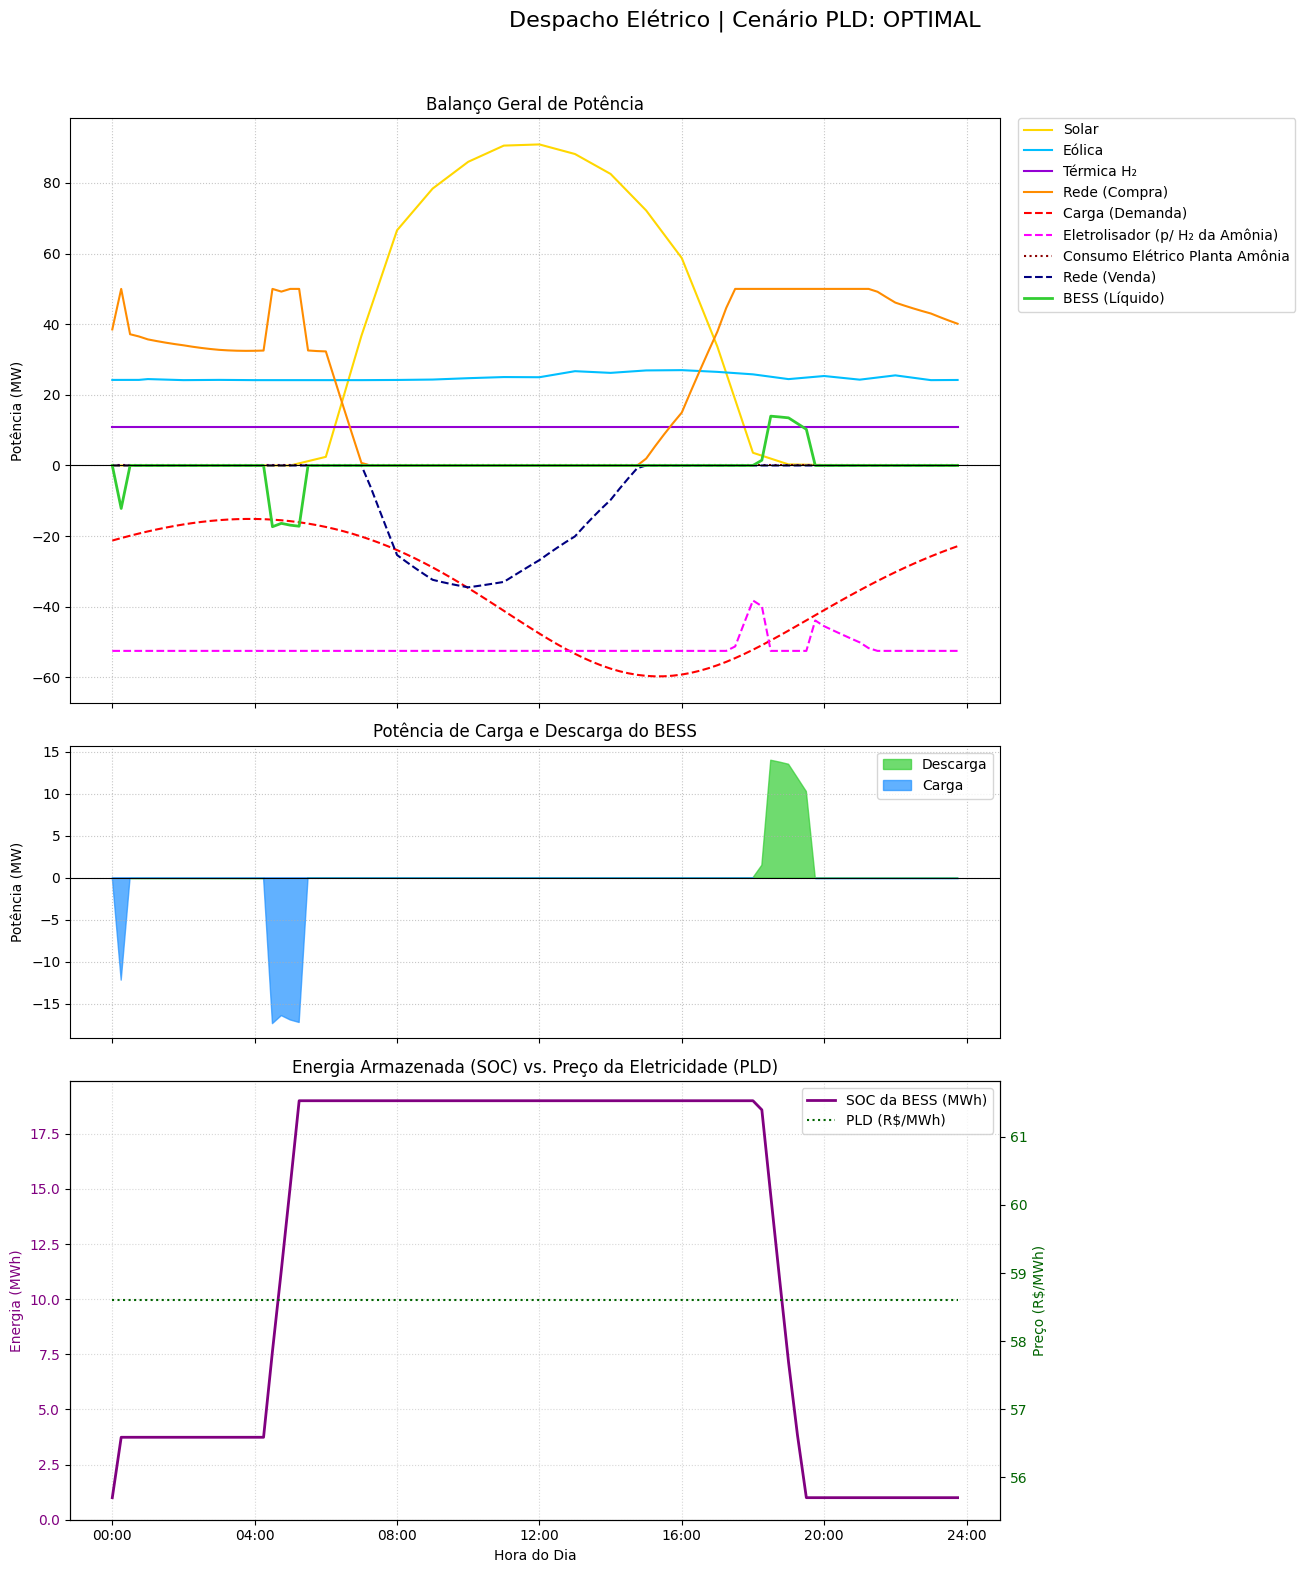

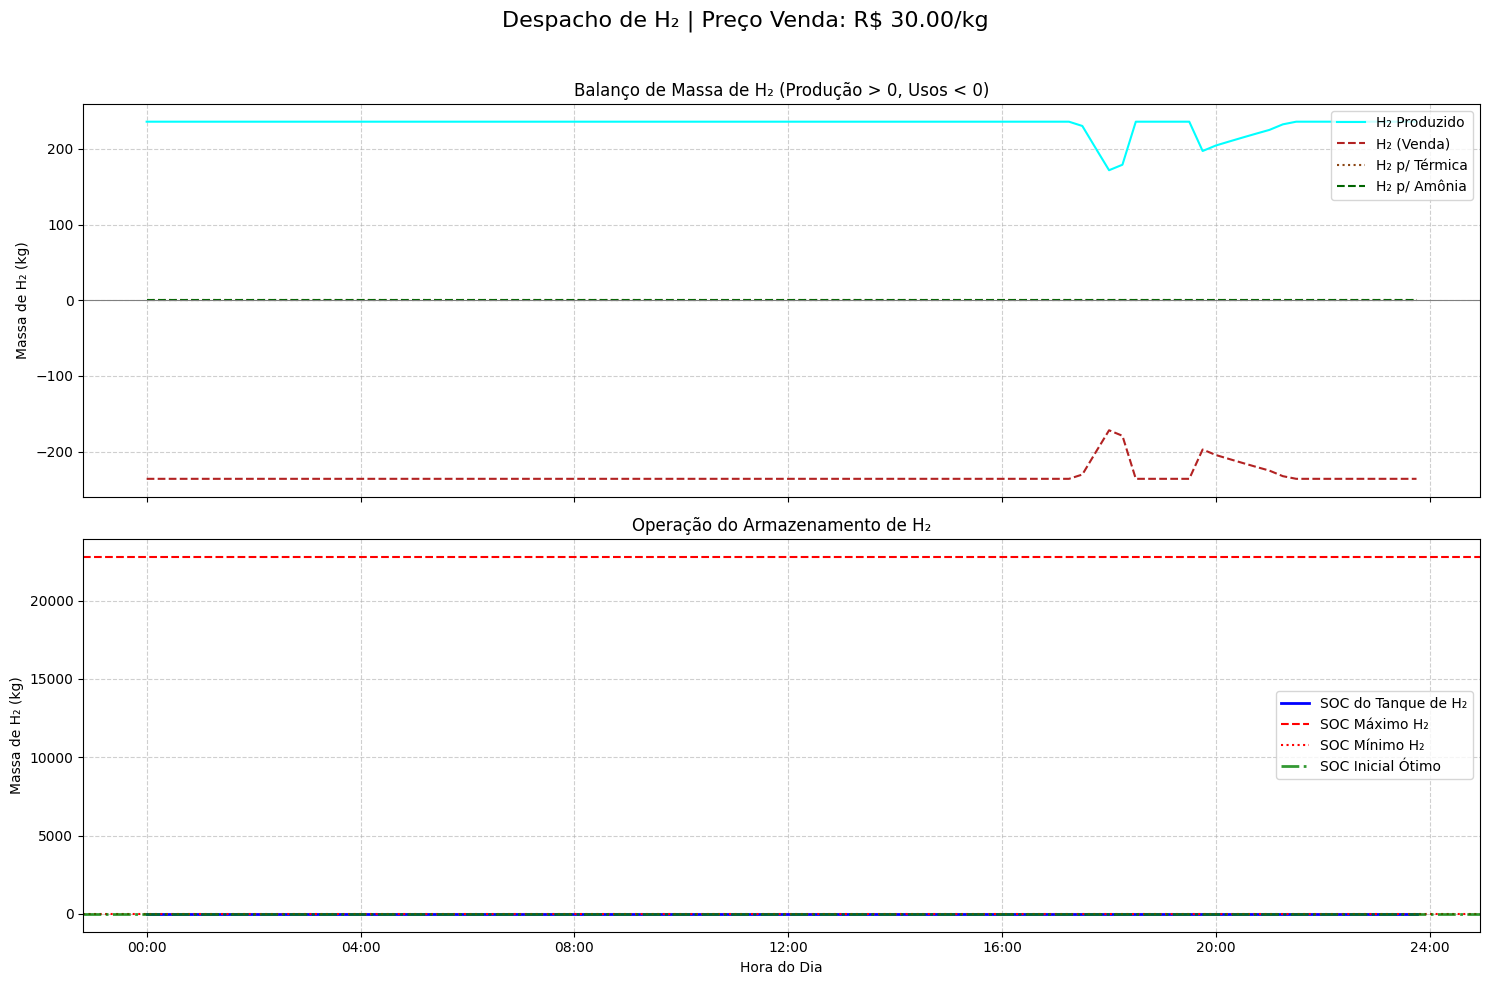

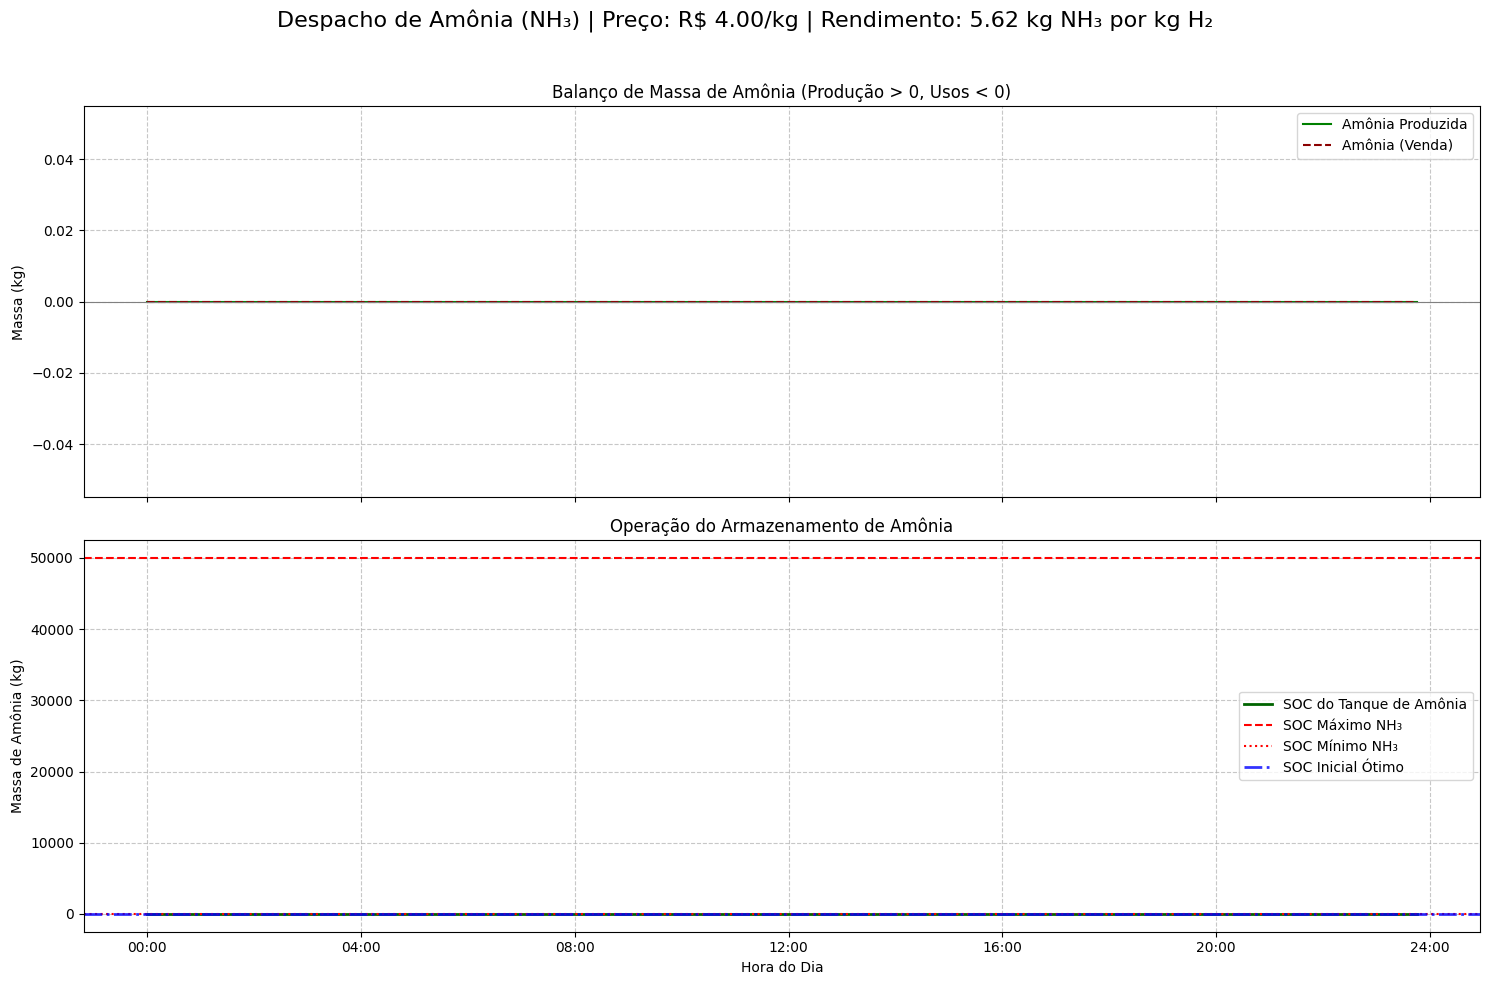

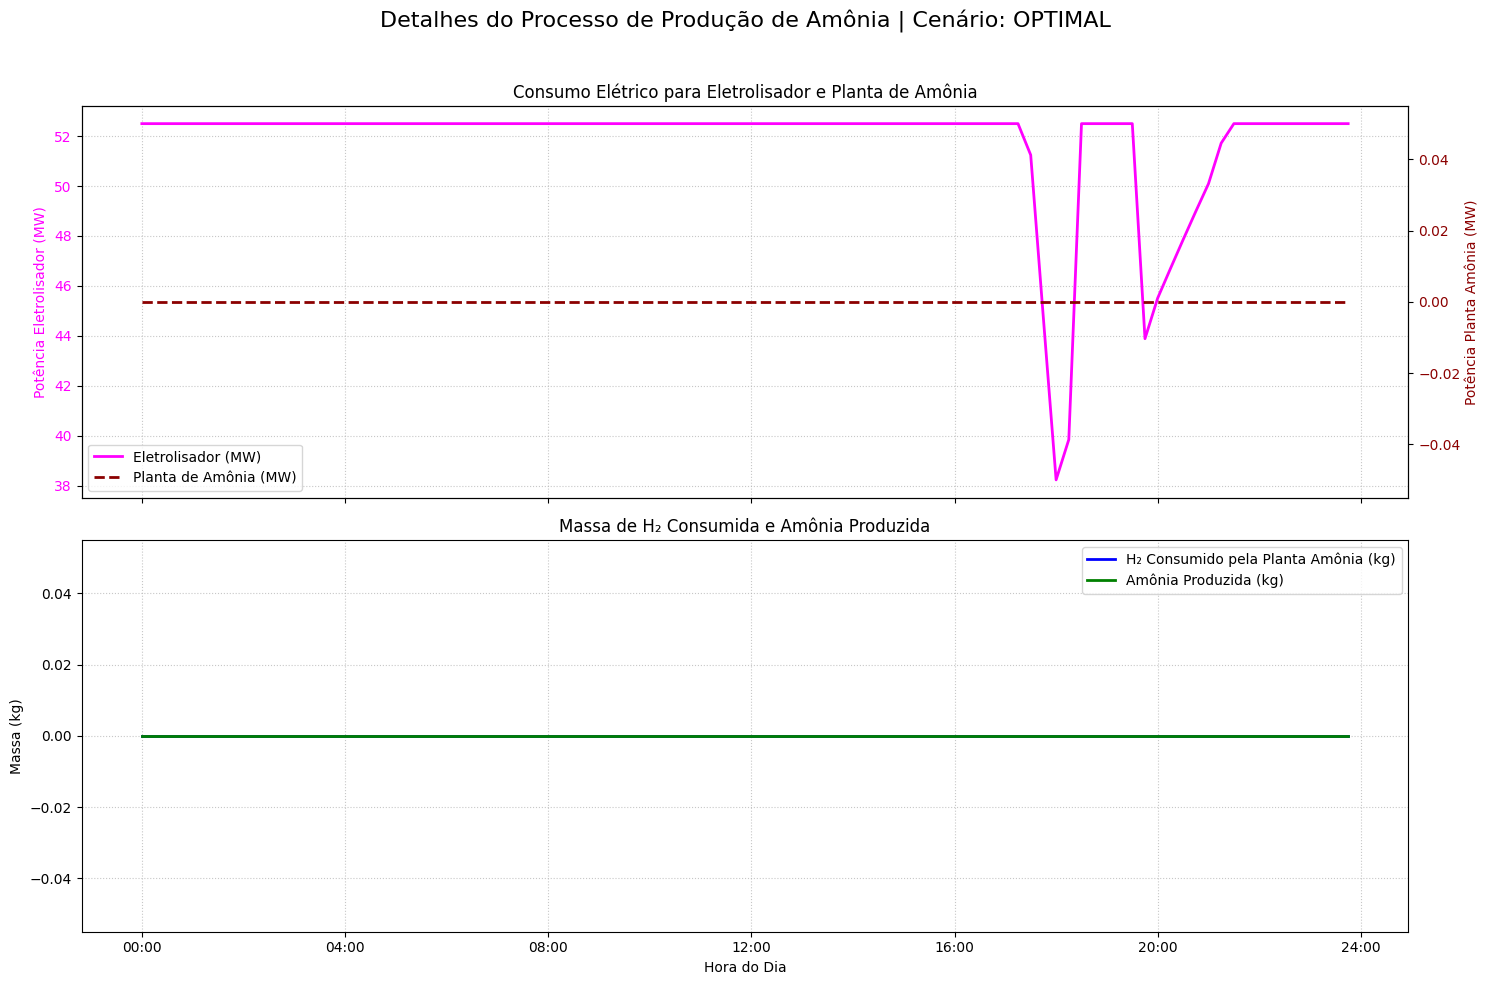

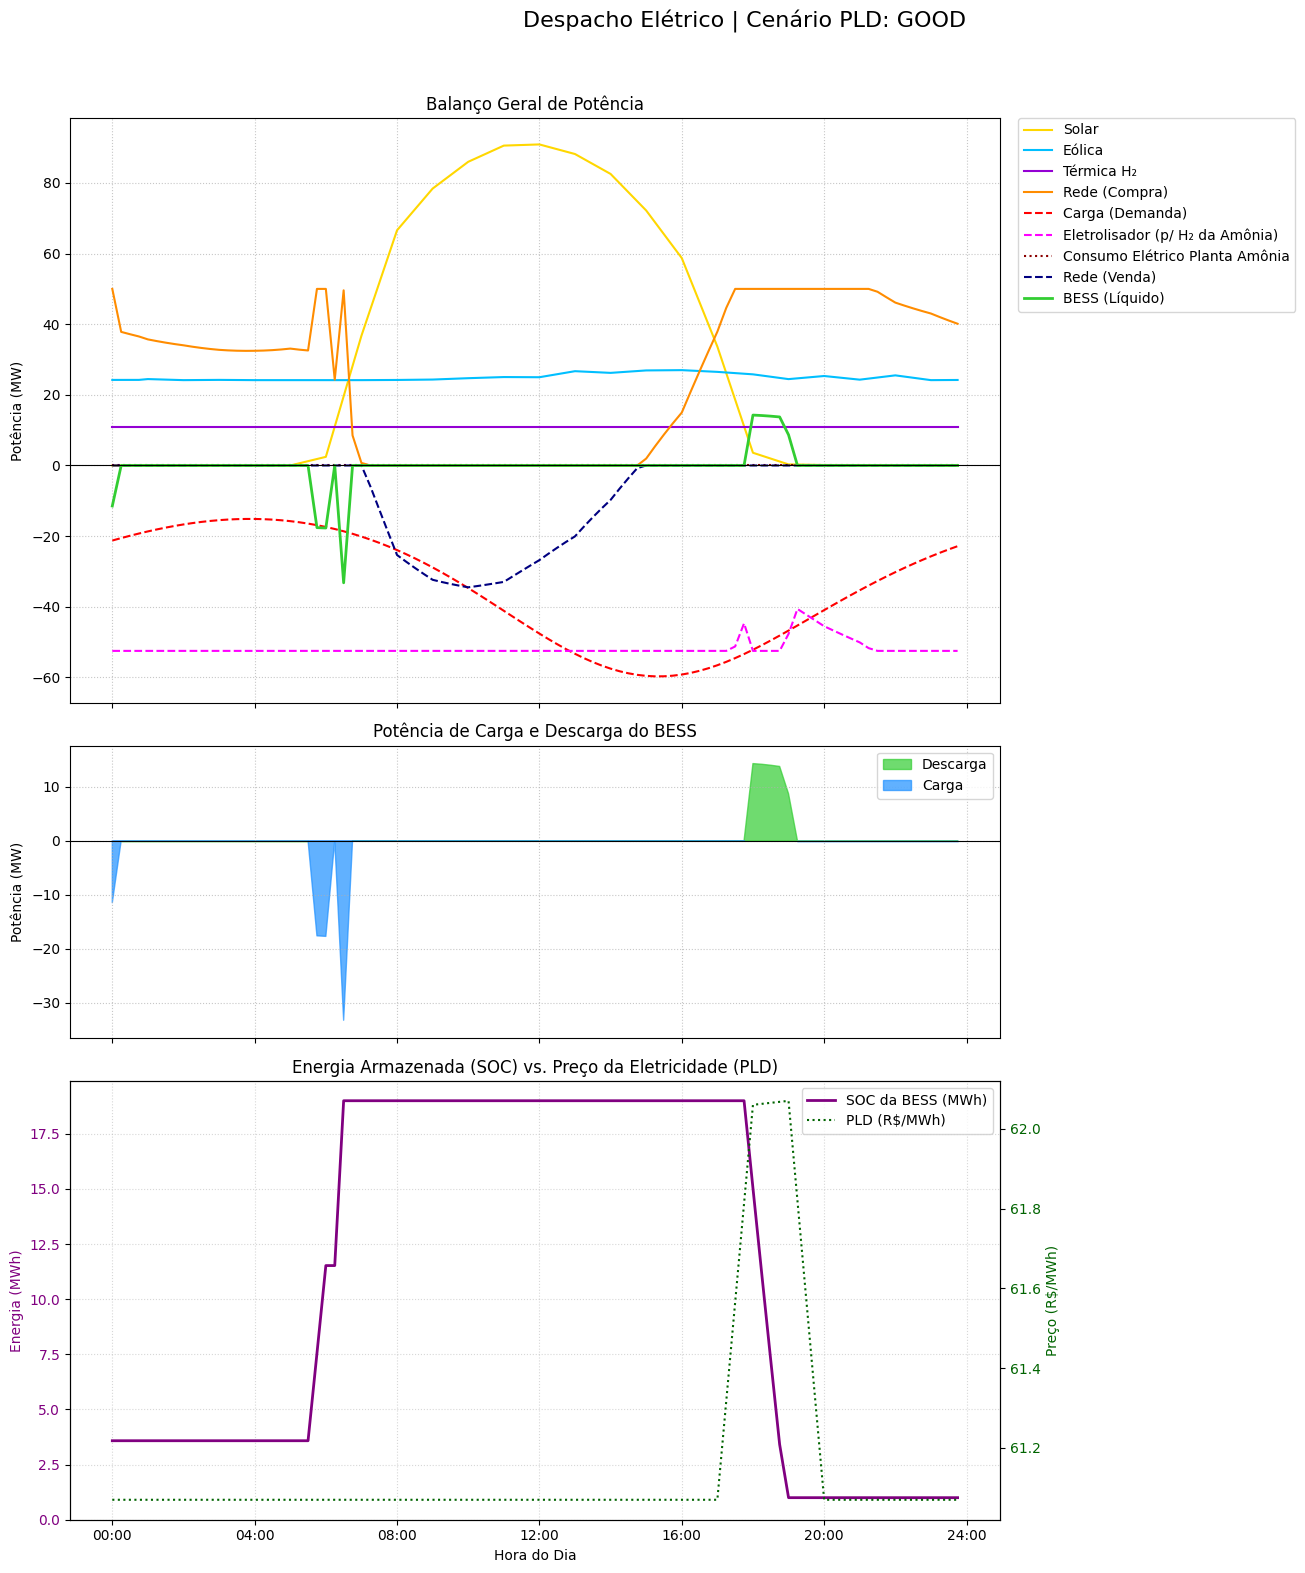

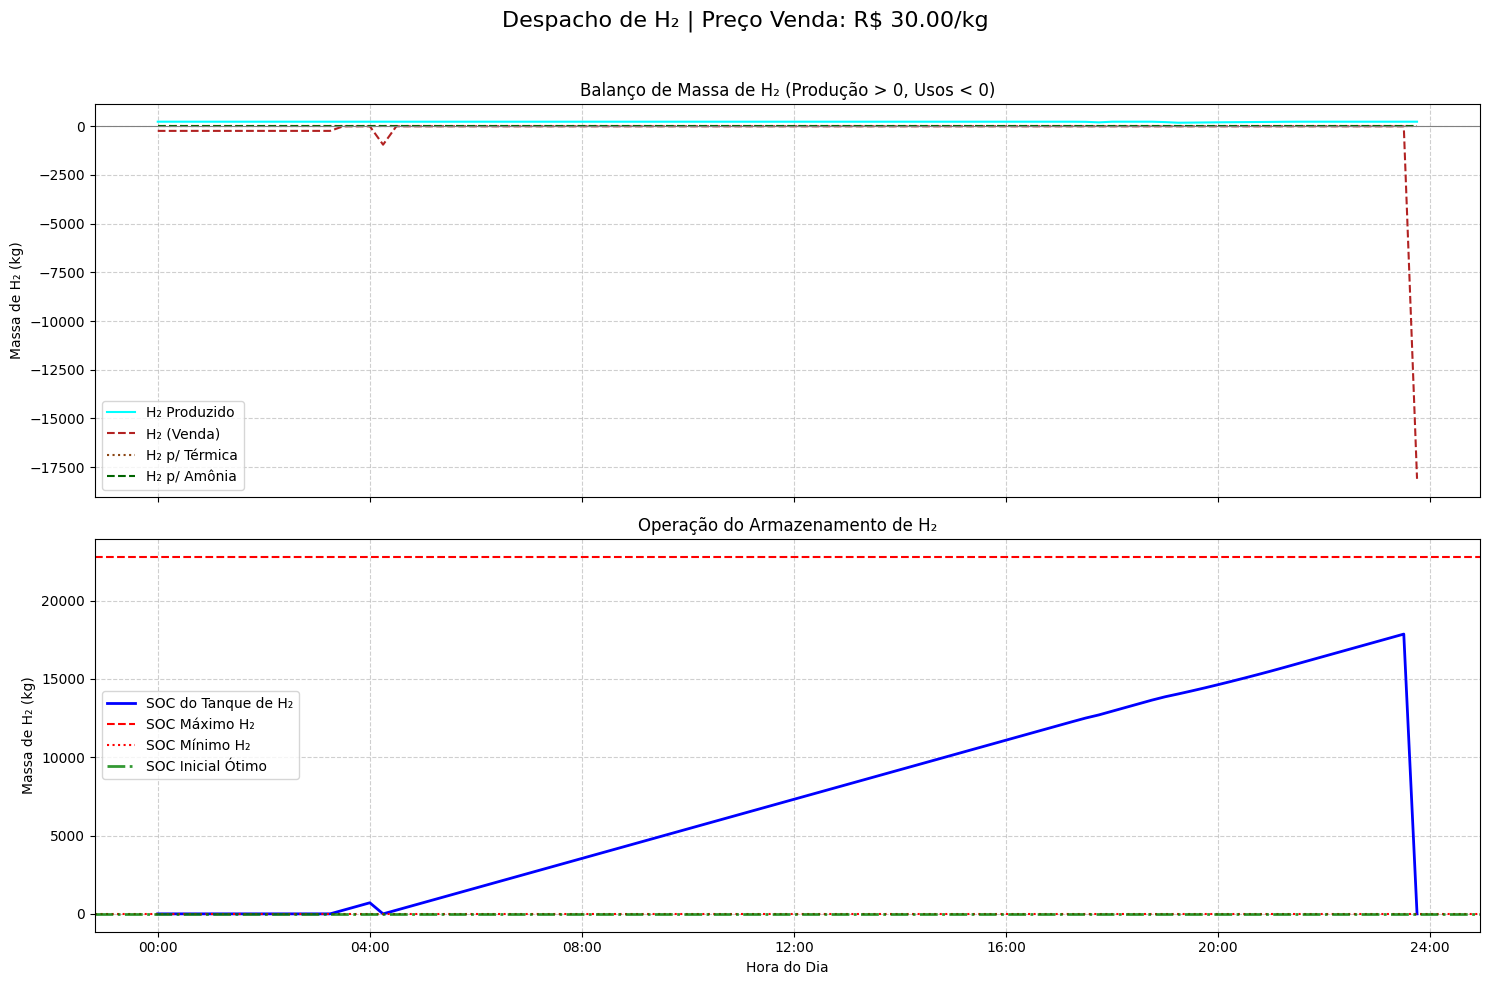

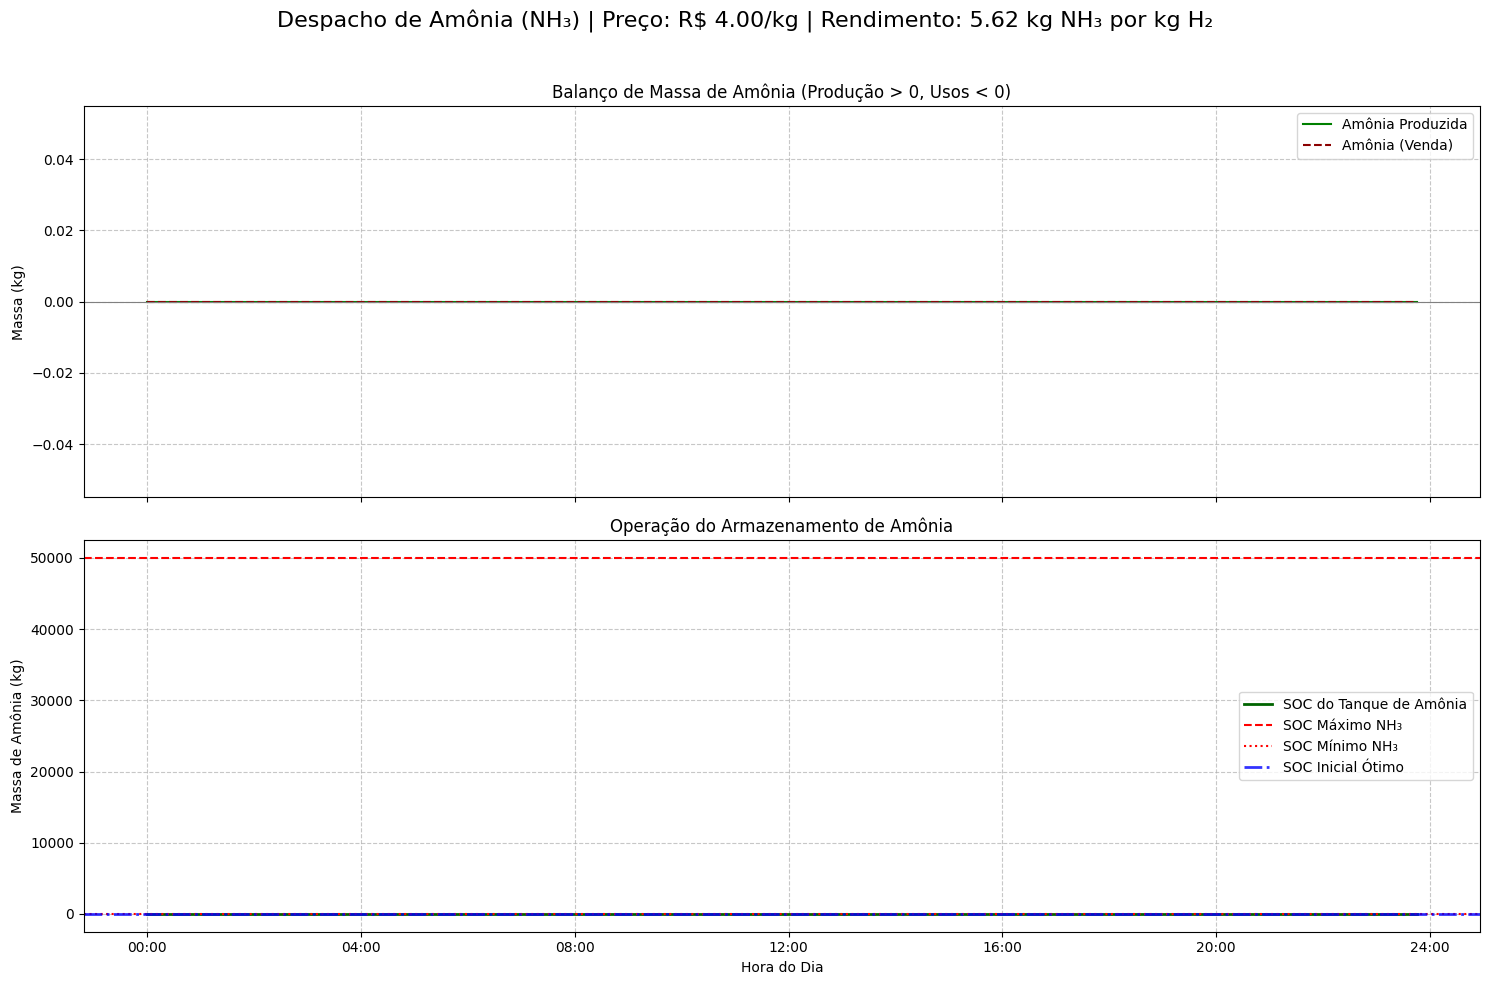

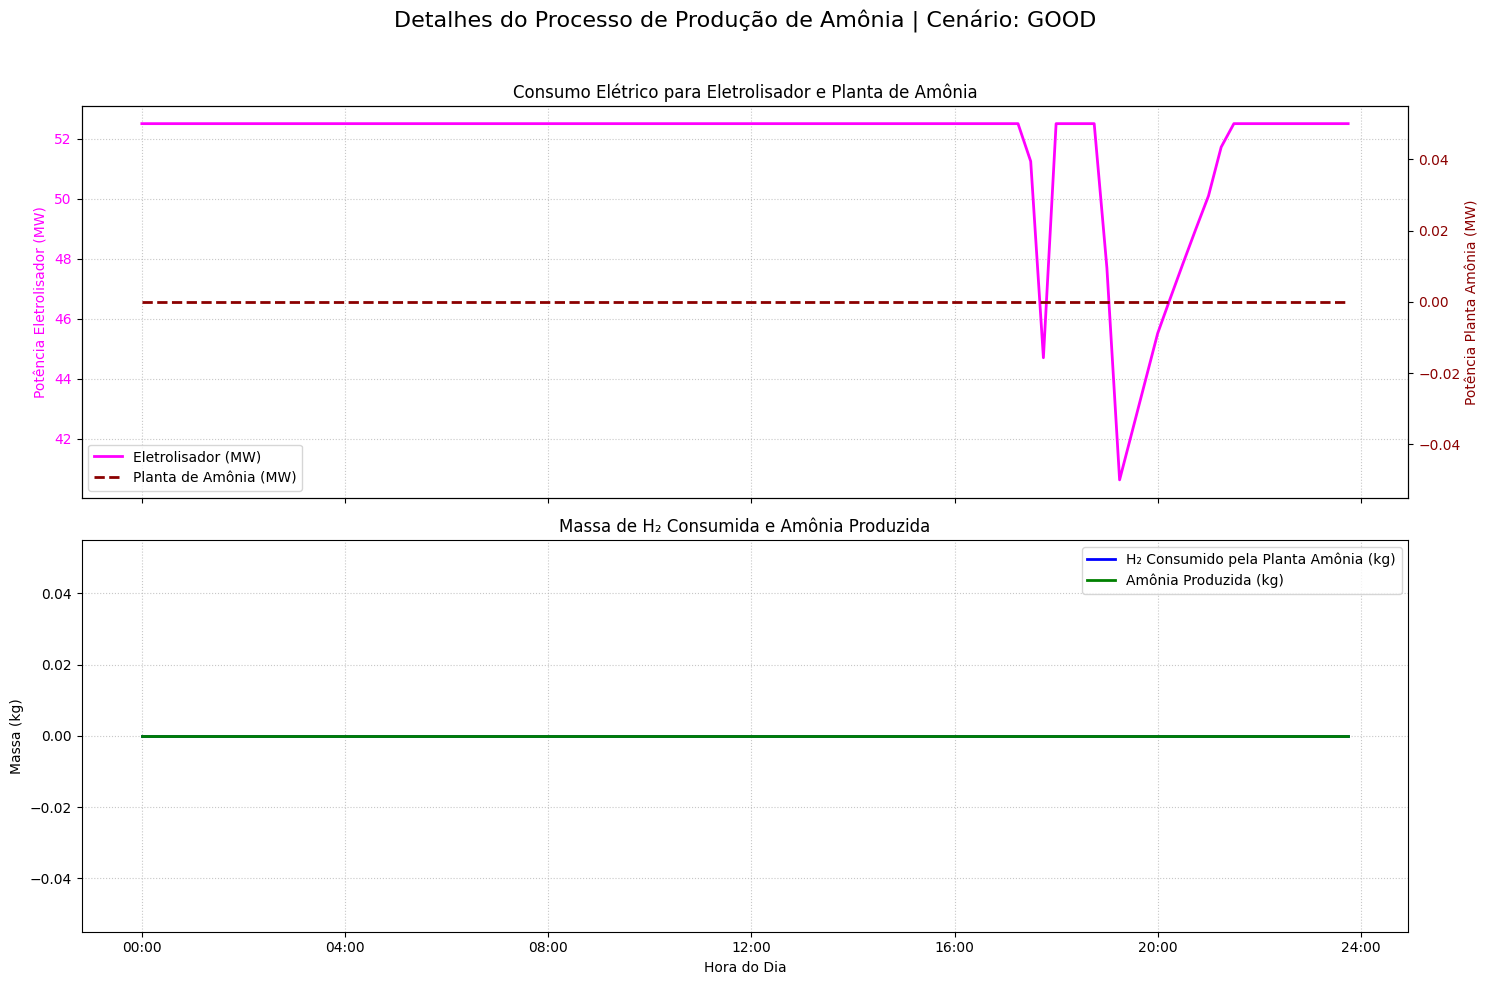

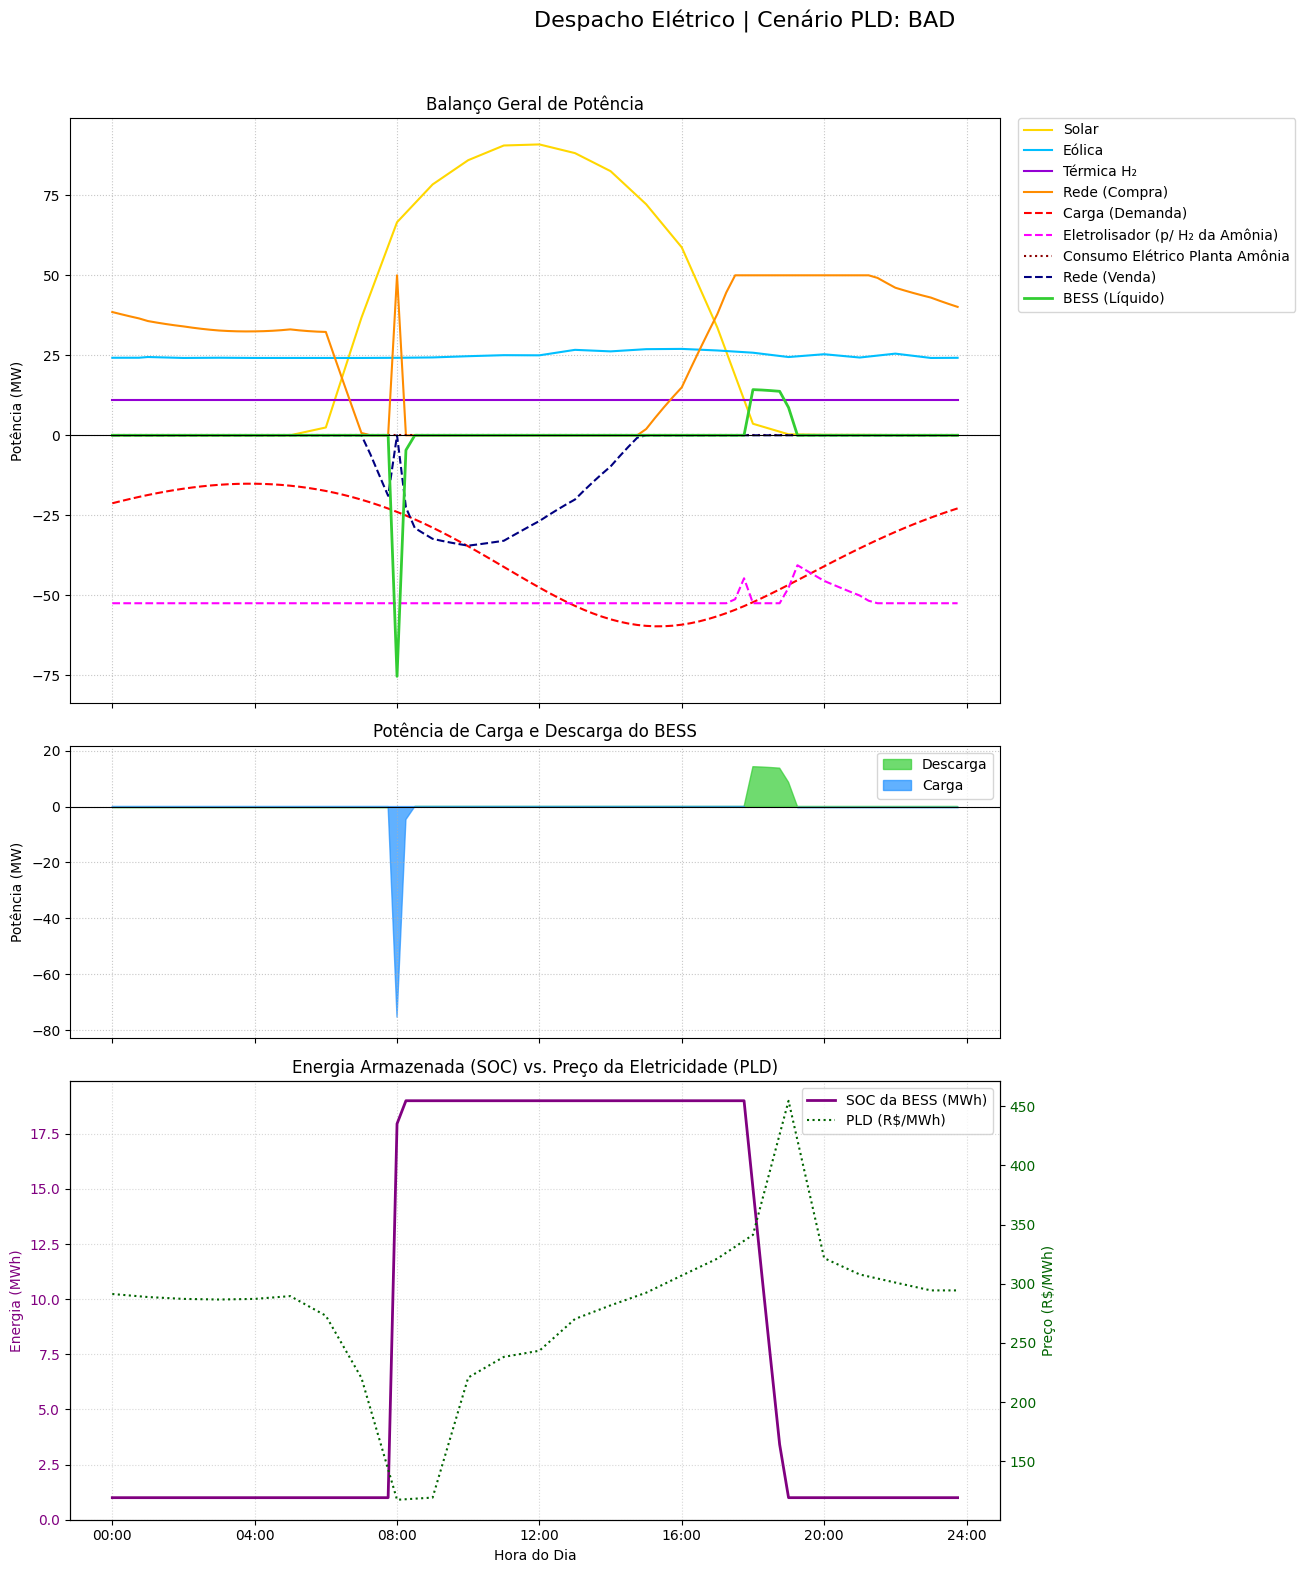

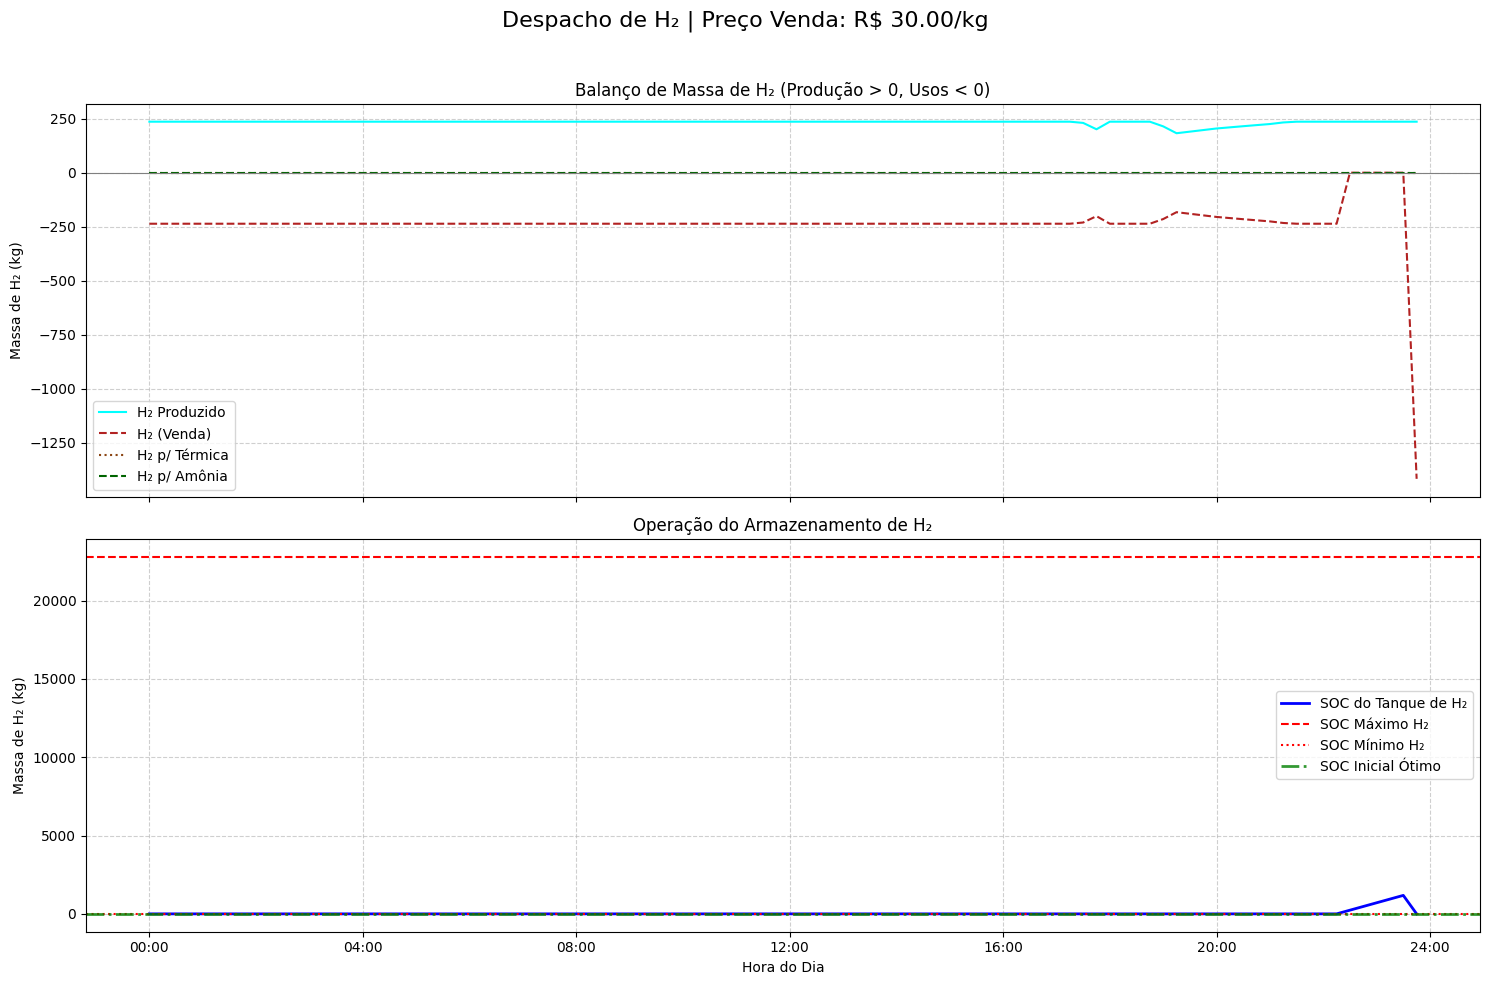

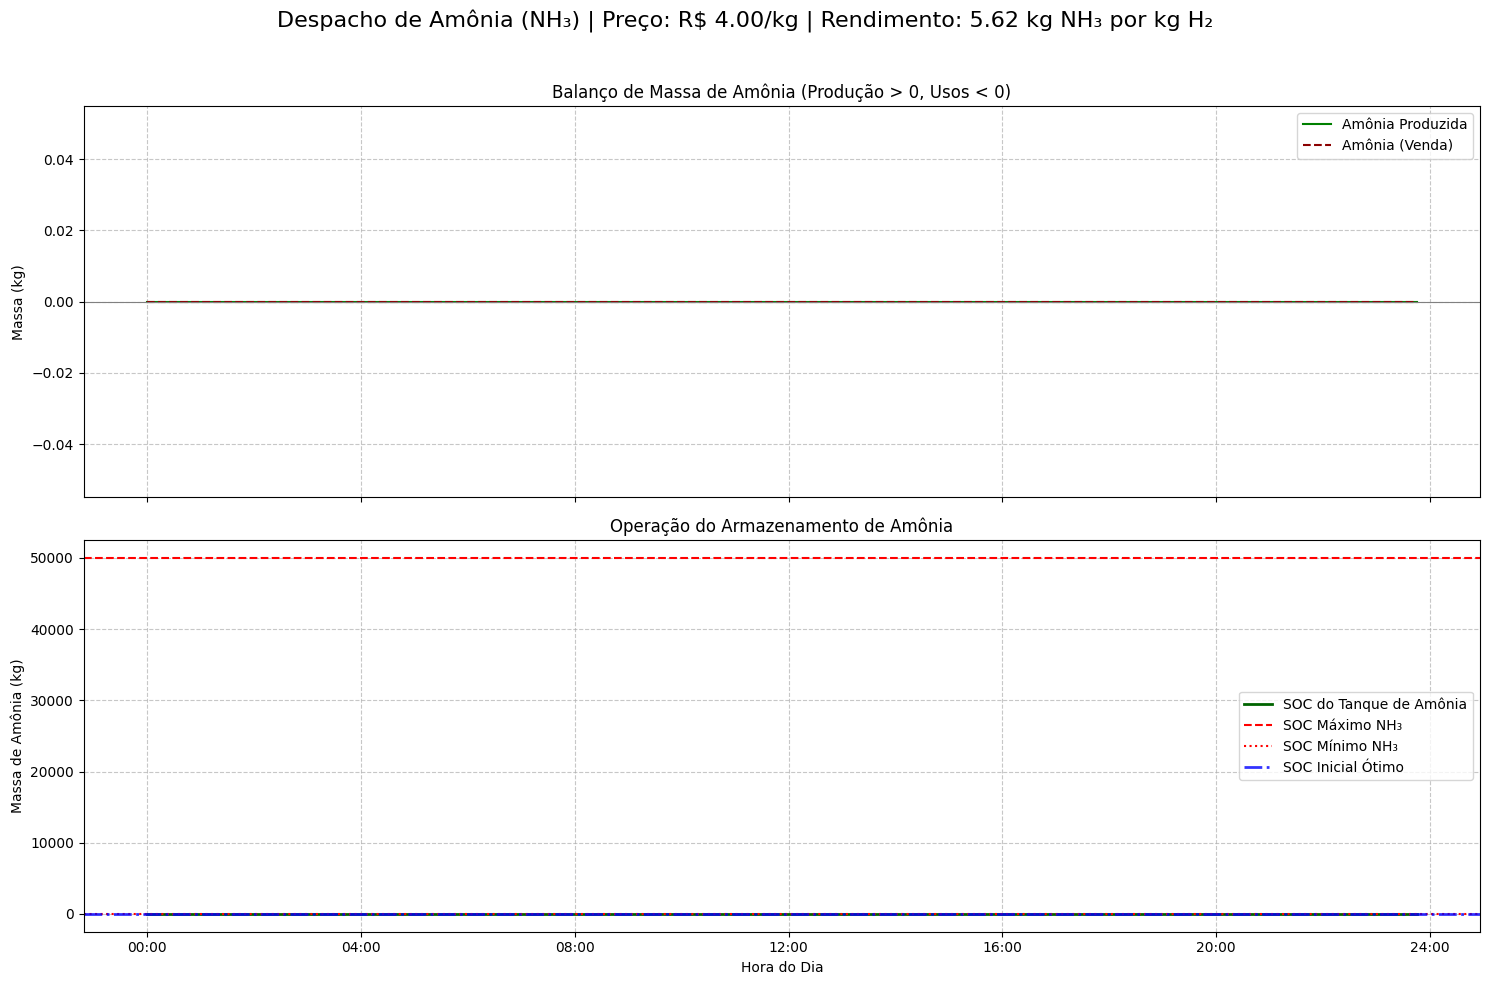

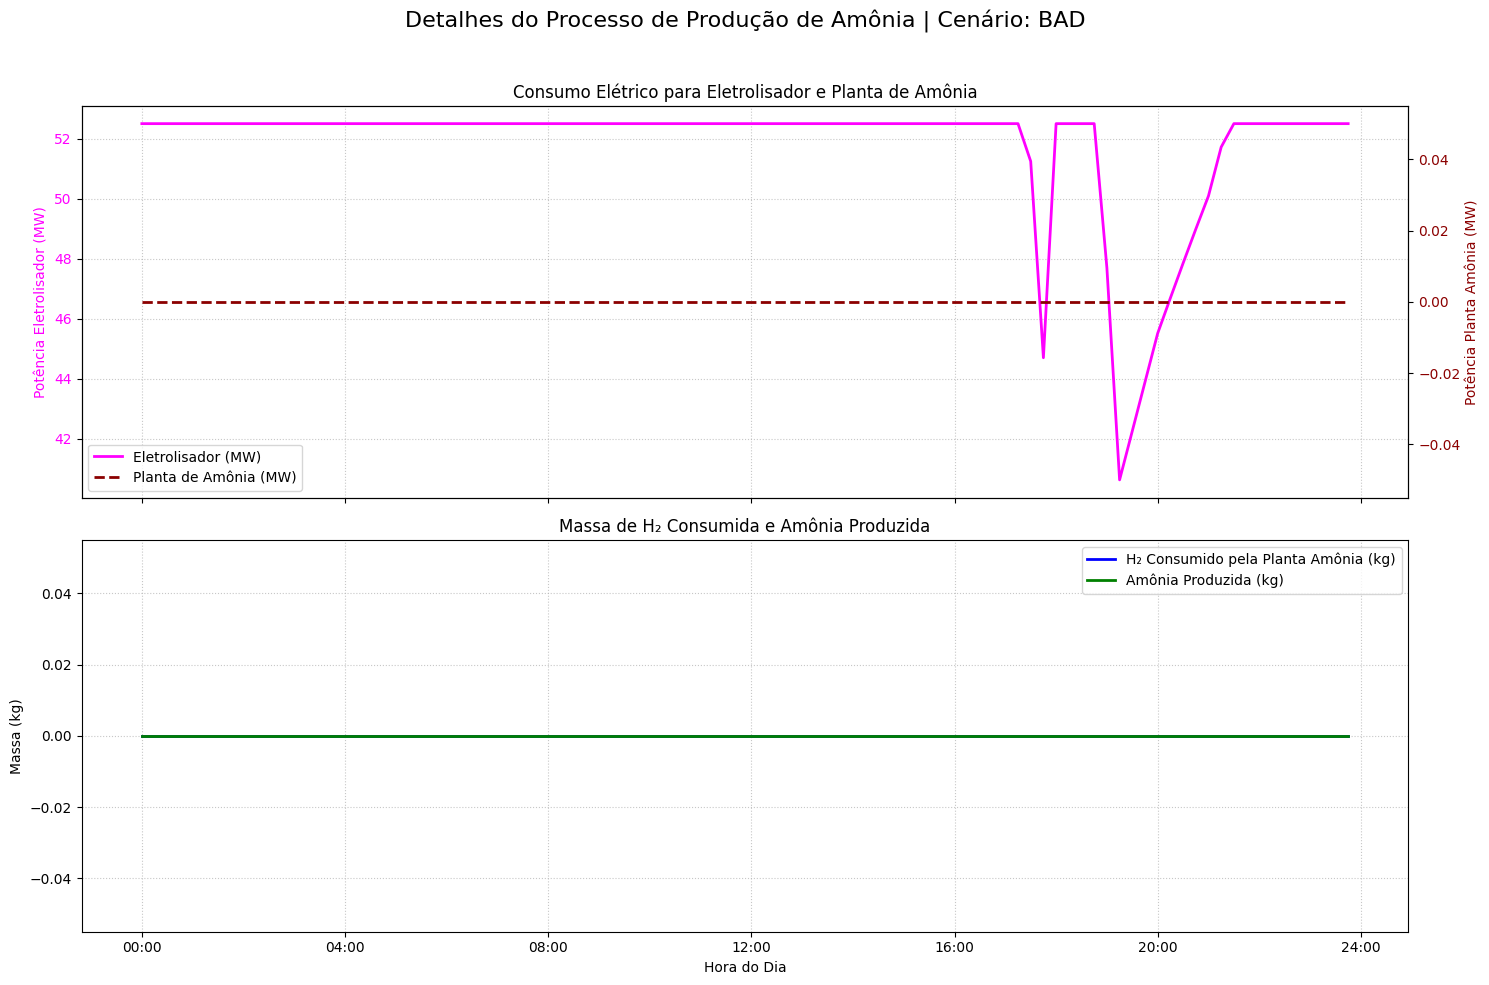

--- Construindo perfis: Preço H₂ (Venda) = R$ 30.00/kg | Preço Amônia (Venda) = R$ 5.50/kg ---
[   22.49] Initializing SPBase

Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.2.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2024.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile '/tmp/tmp4ek12m_f.cplex.log' open.
CPLEX> Problem '/tmp/tmpvh3xmwa1.pyomo.lp' read.
Read time = 0.00 sec. (0.25 ticks)
CPLEX> Problem name         : /tmp/tmpvh3xmwa1.pyomo.lp
Objective sense      : Maximize
Variables            :    4617  [Nneg: 2601,  Box: 2016]
Objective nonzeros   :    1440
Linear constraints   :    1743  [Less: 9,  Equal: 1734]
  Nonzeros           :    7518
  RHS nonzeros       :     288

Variables            : Min LB: 0.000000         Max UB: 5.250

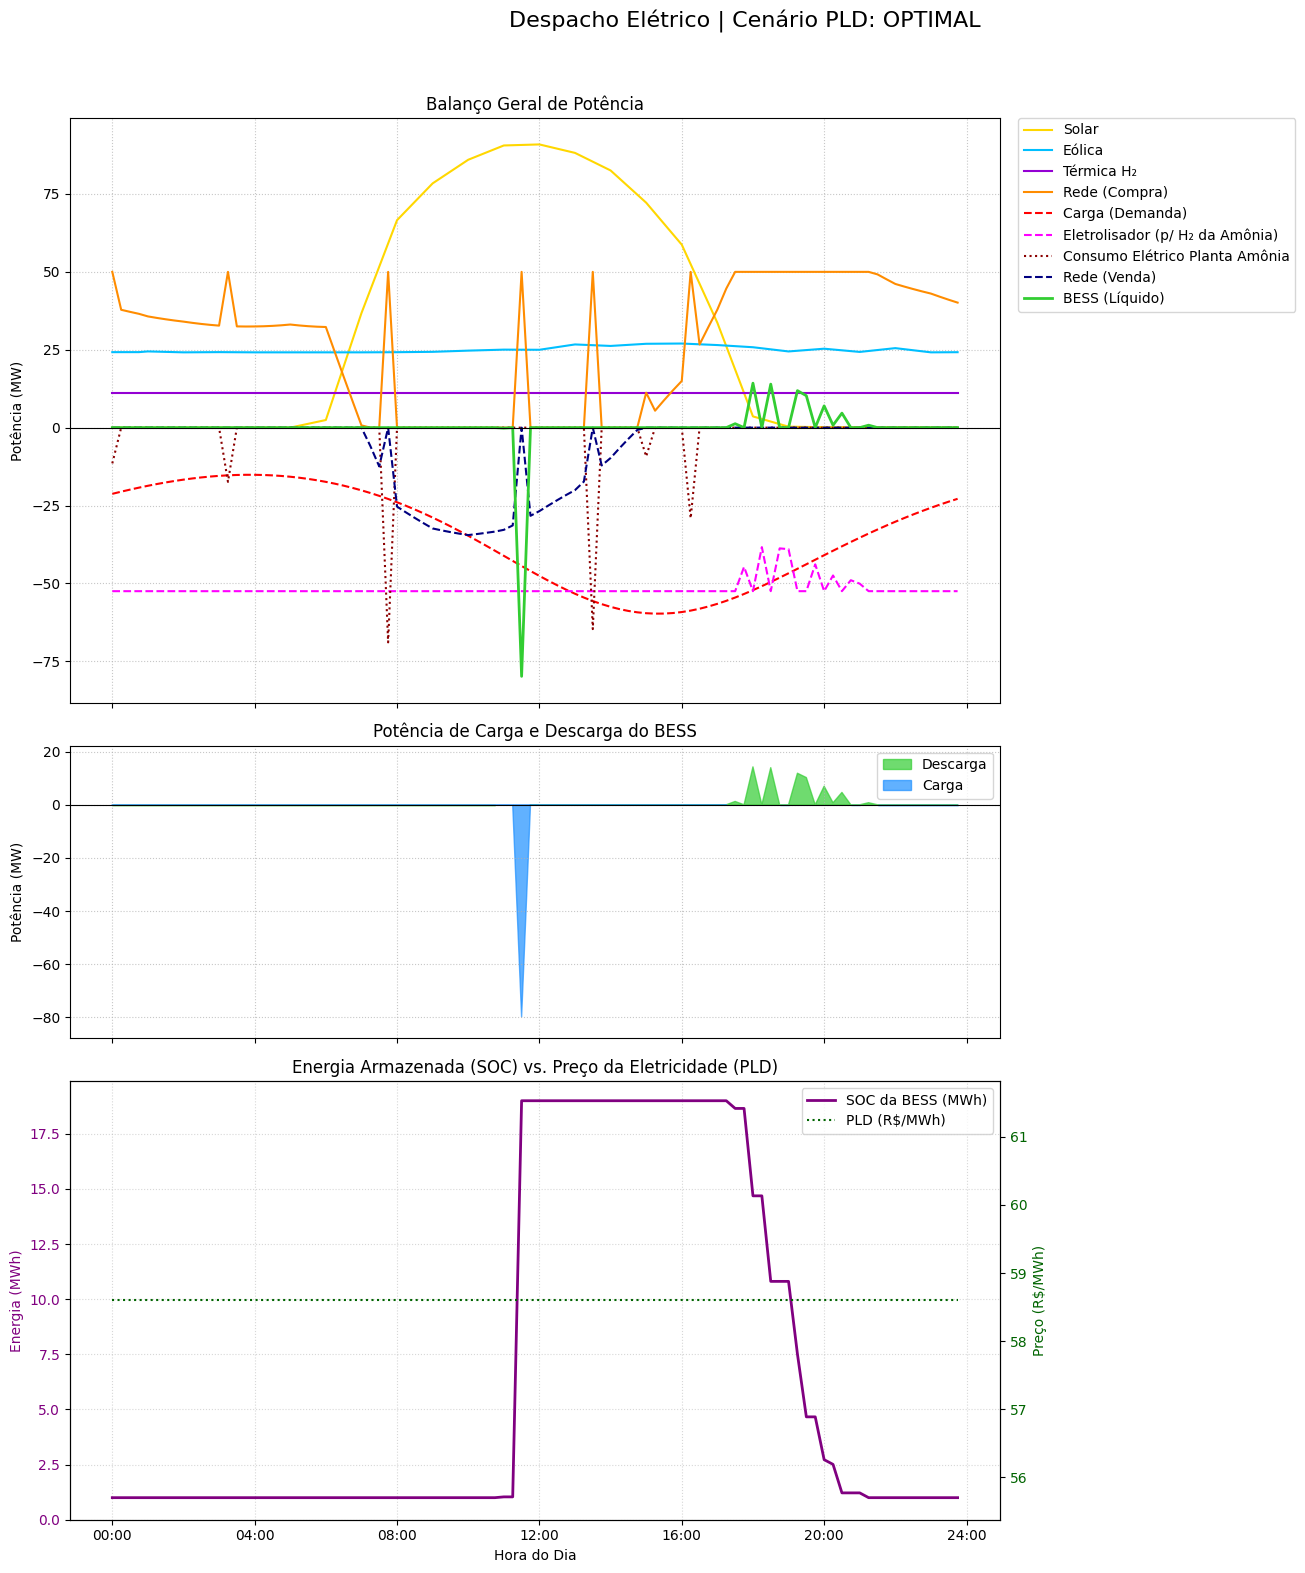

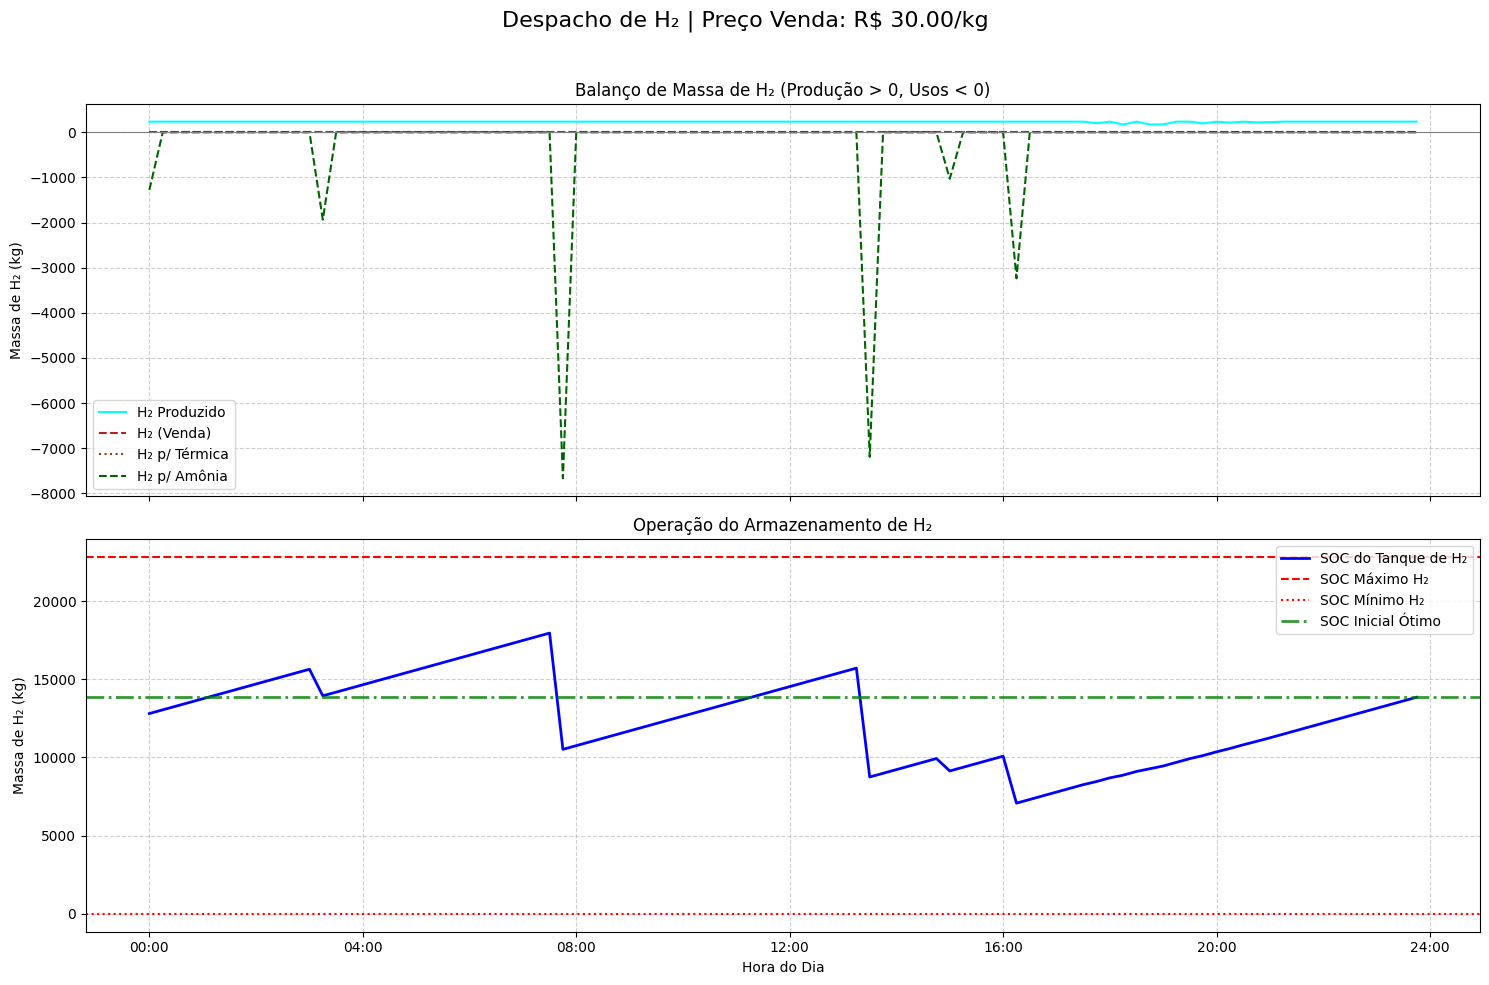

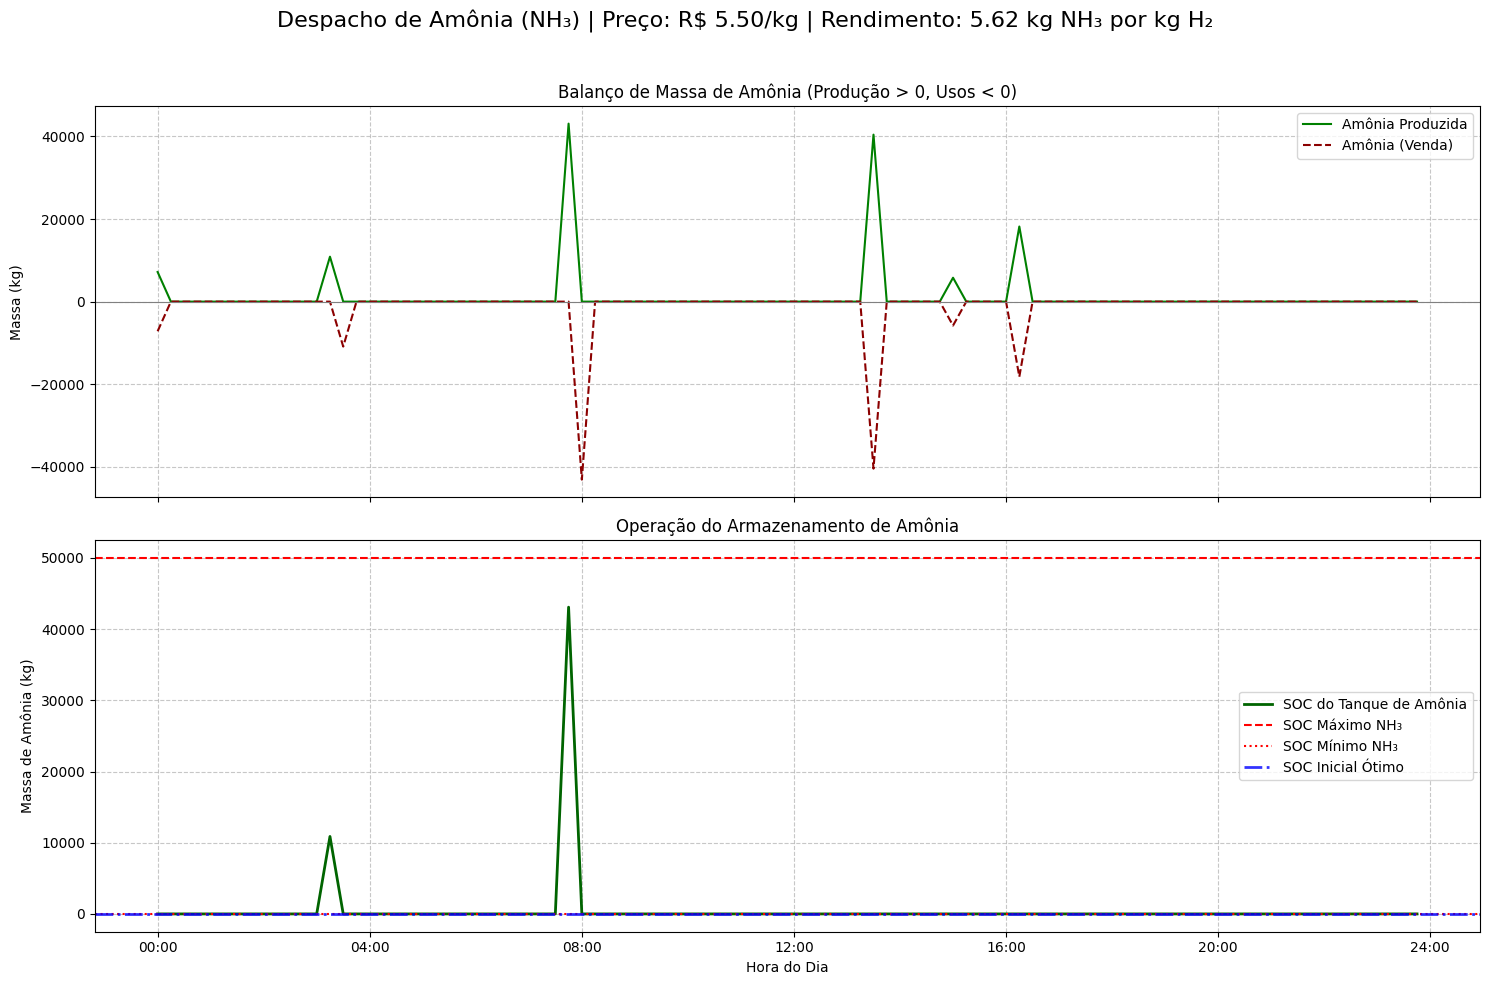

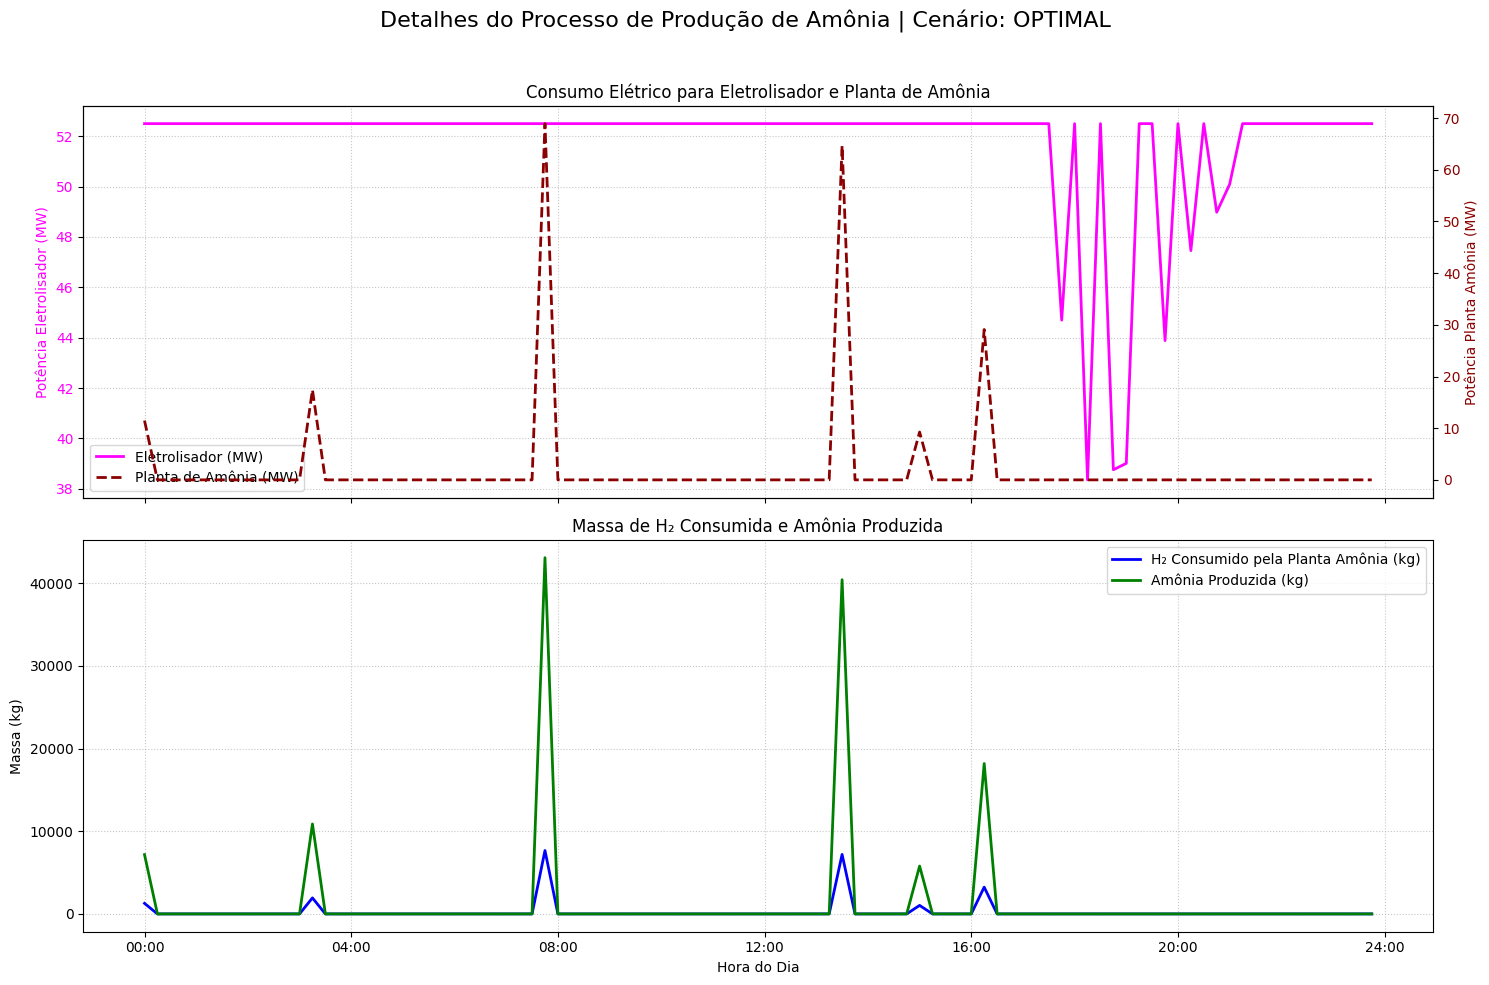

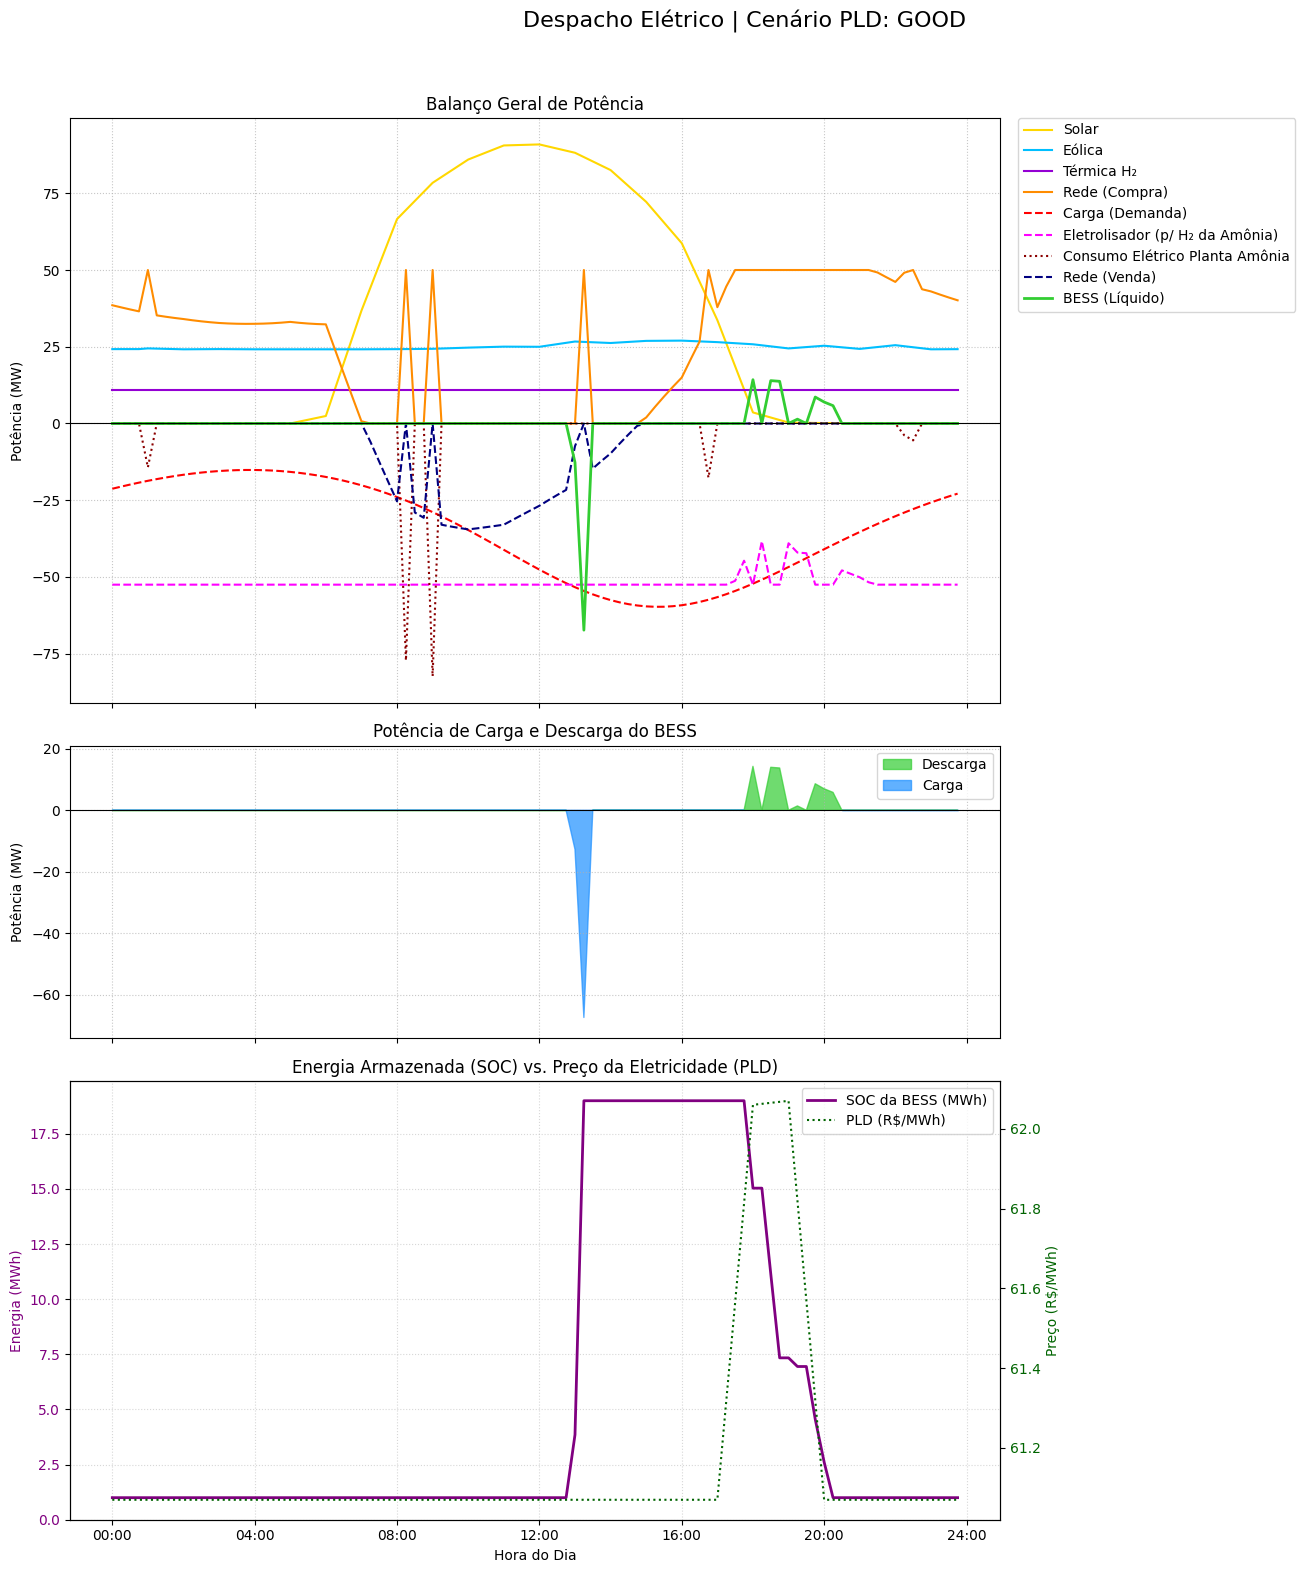

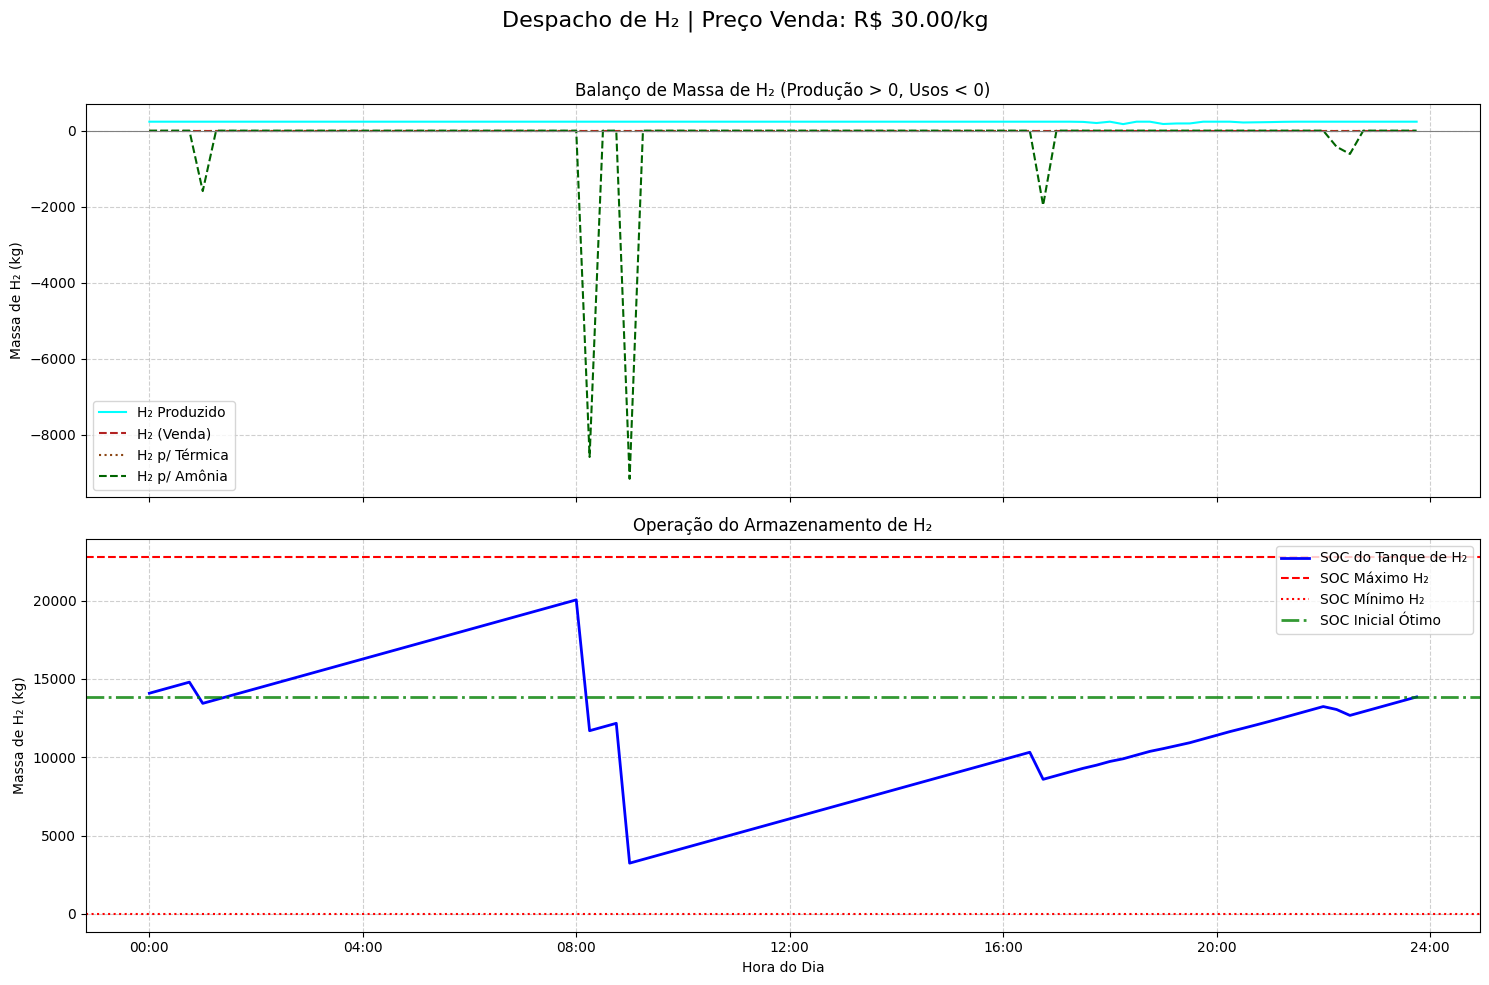

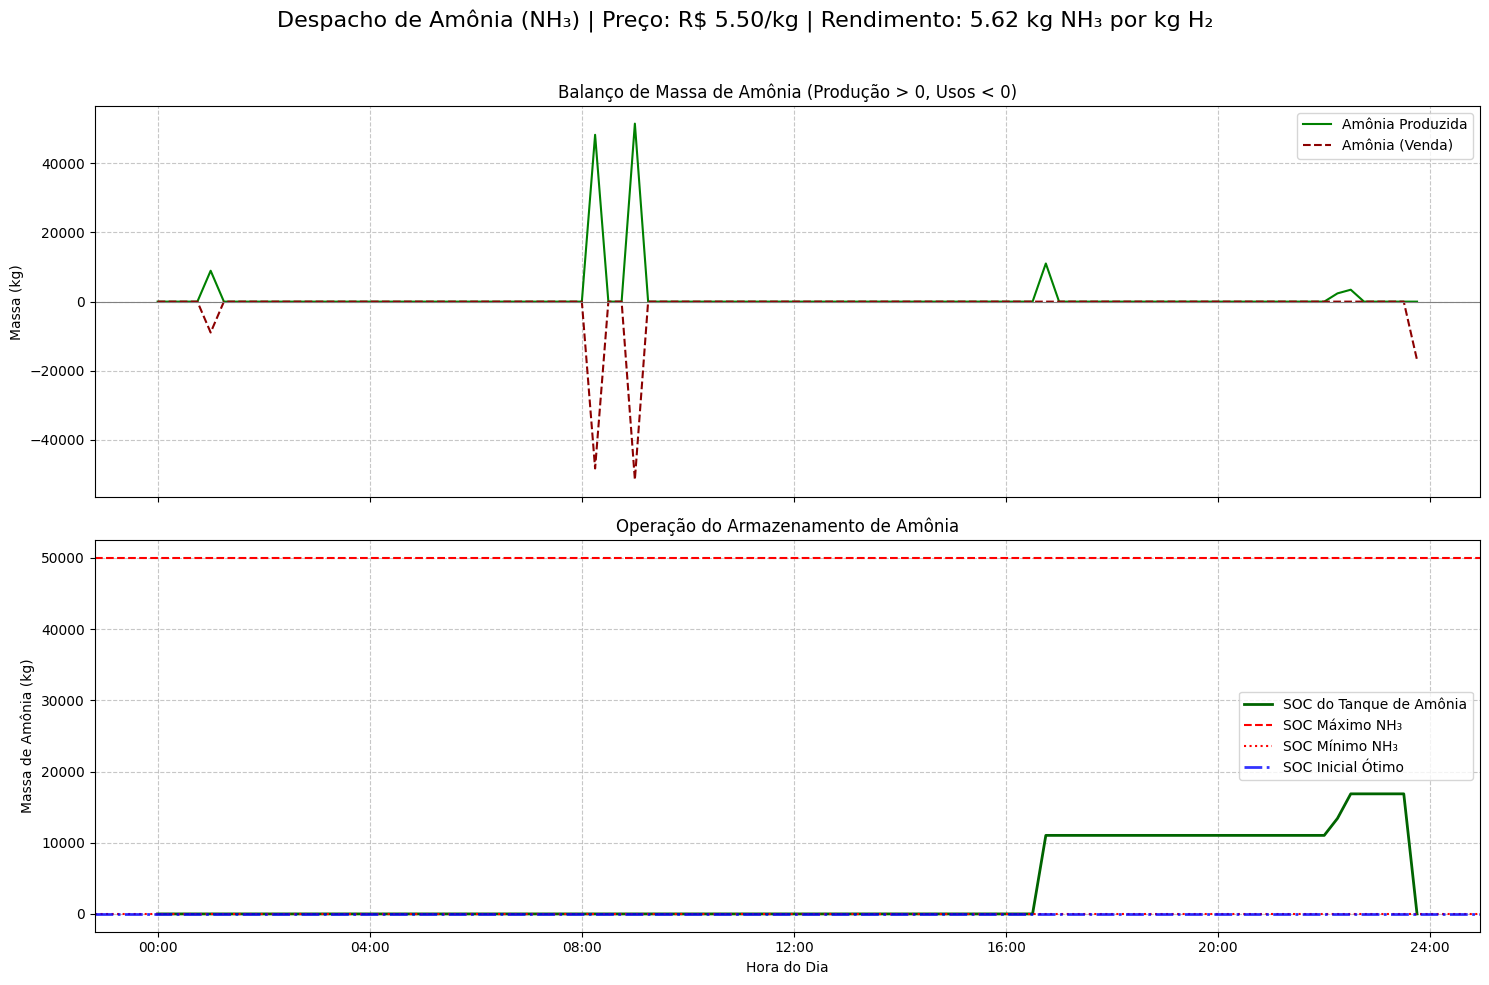

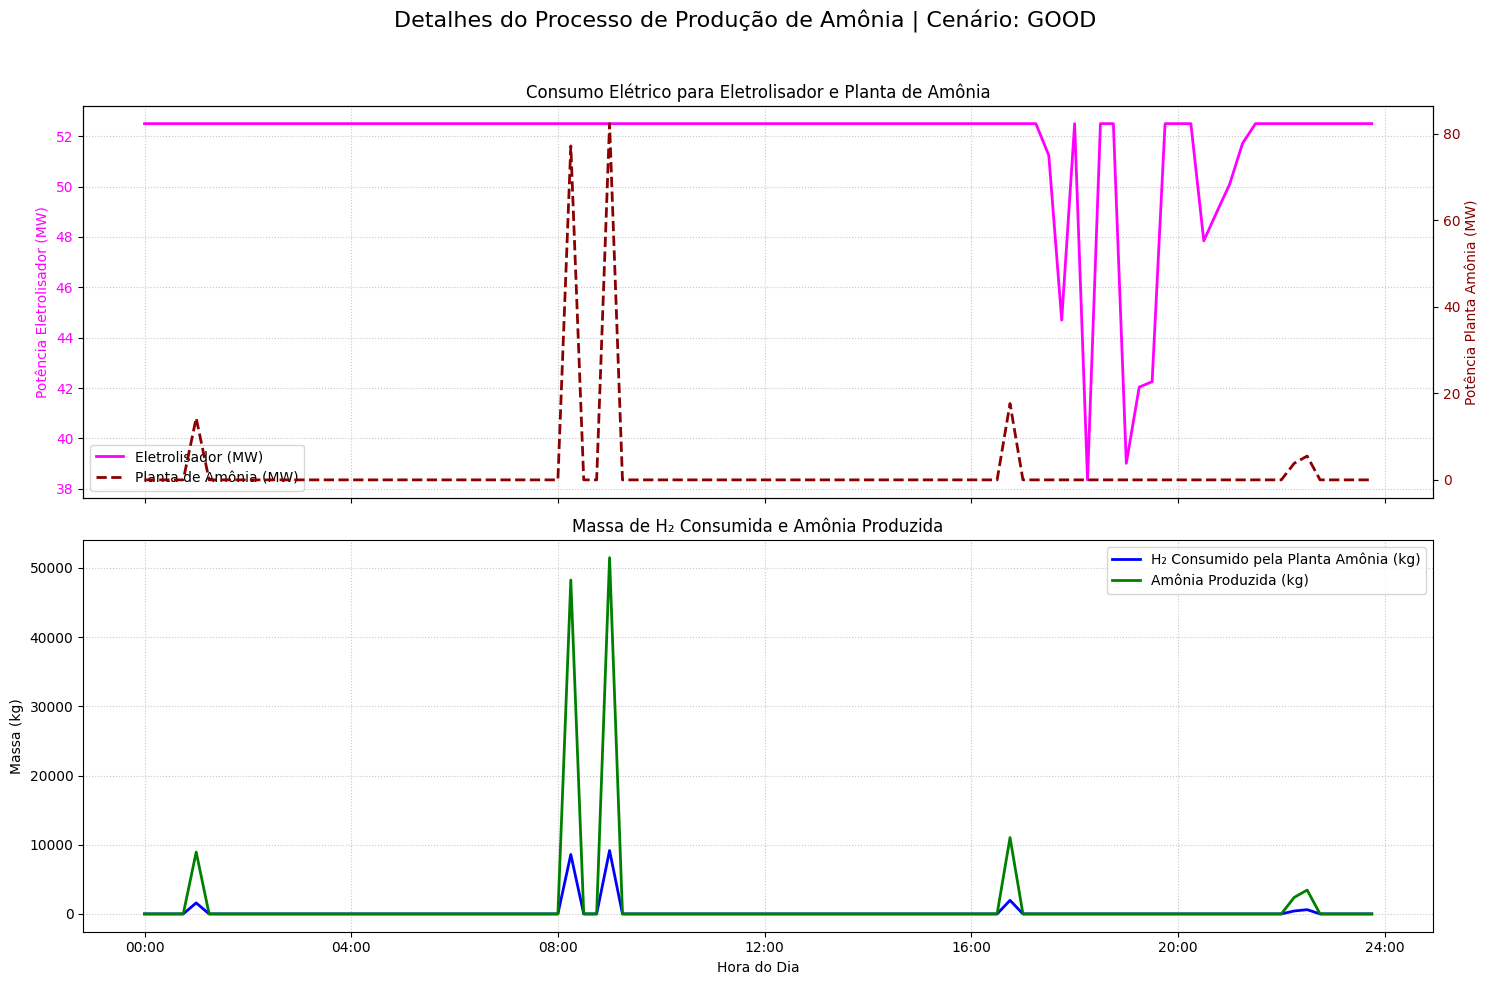

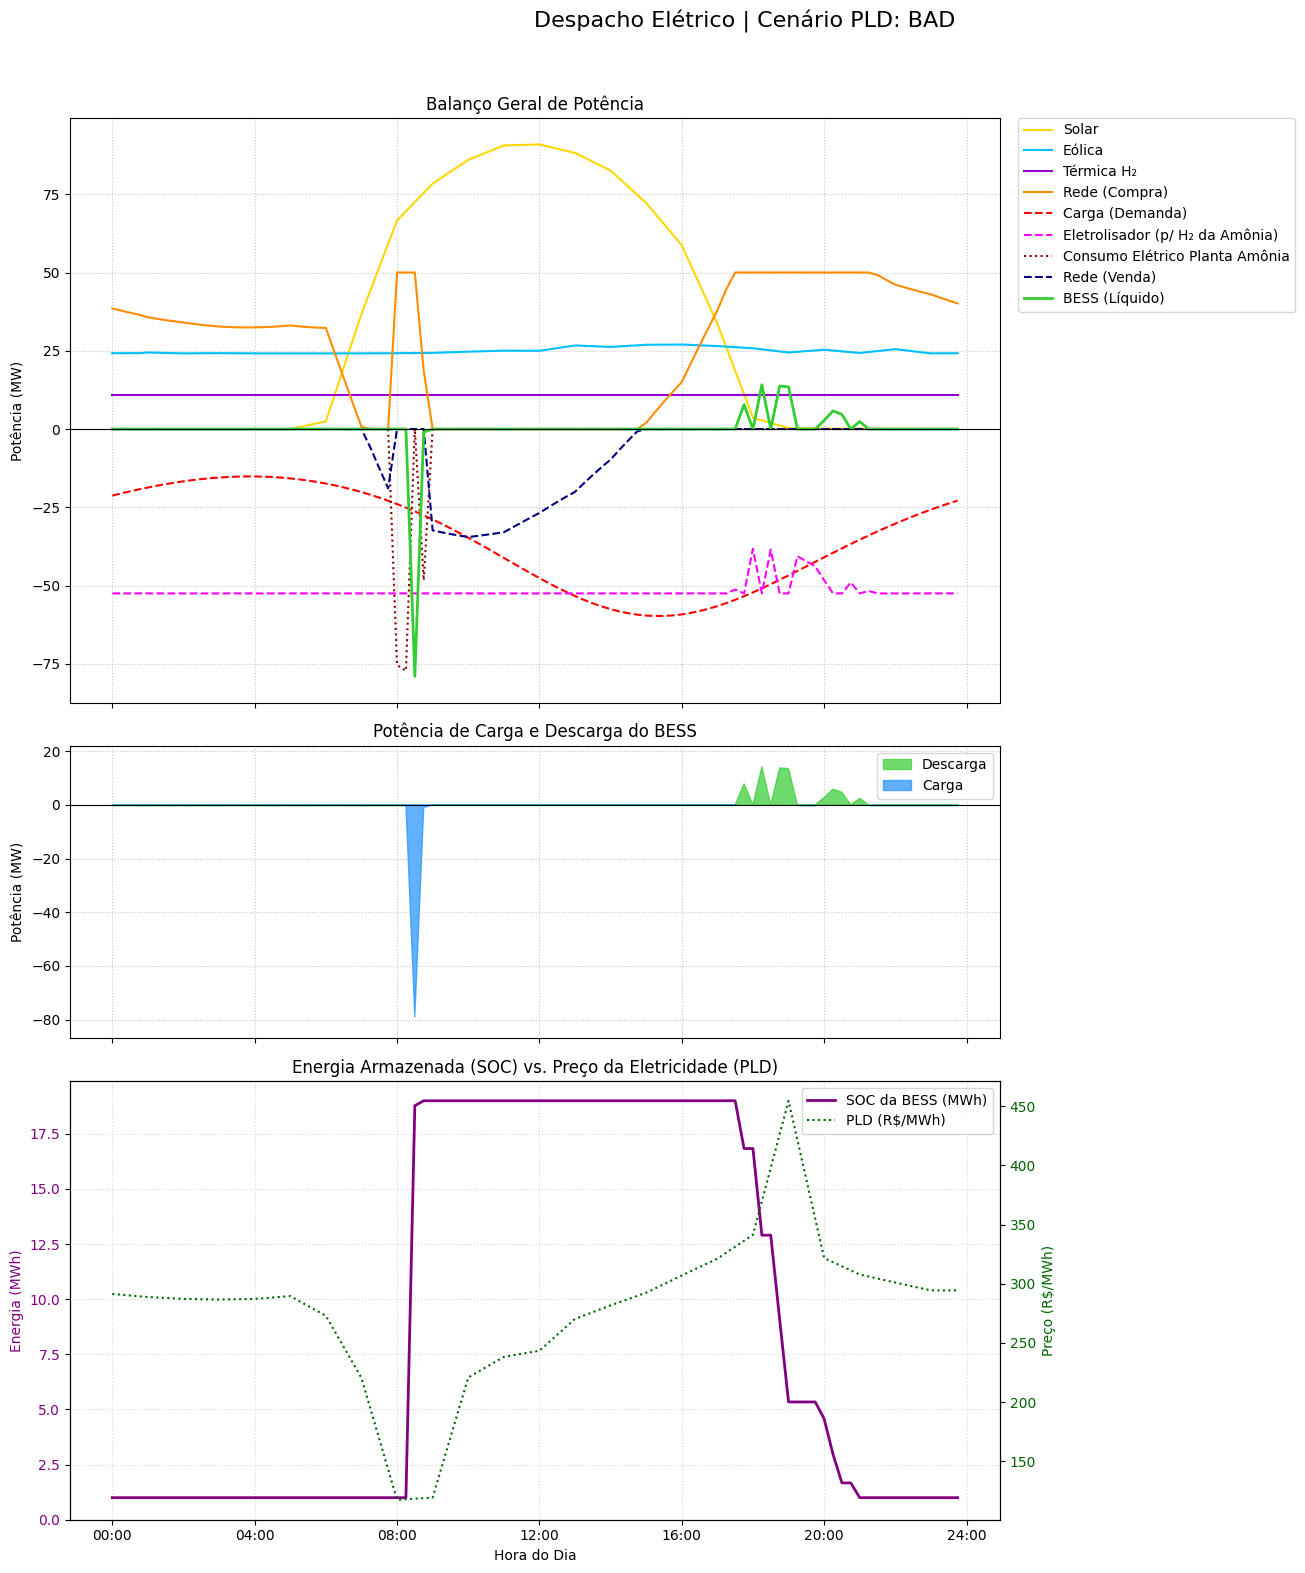

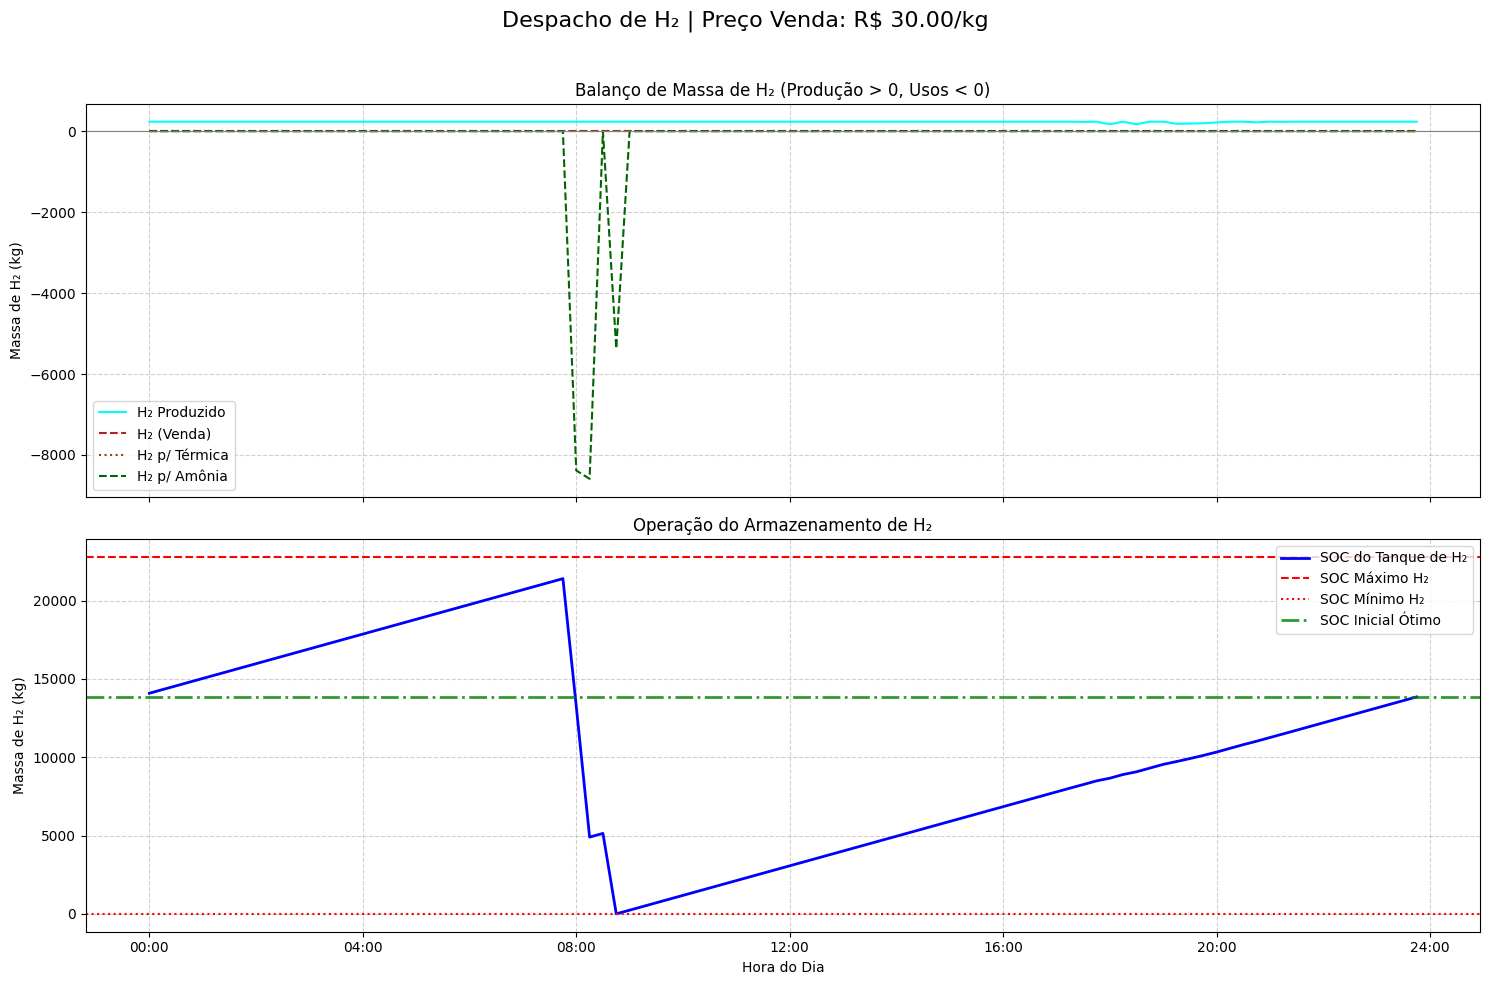

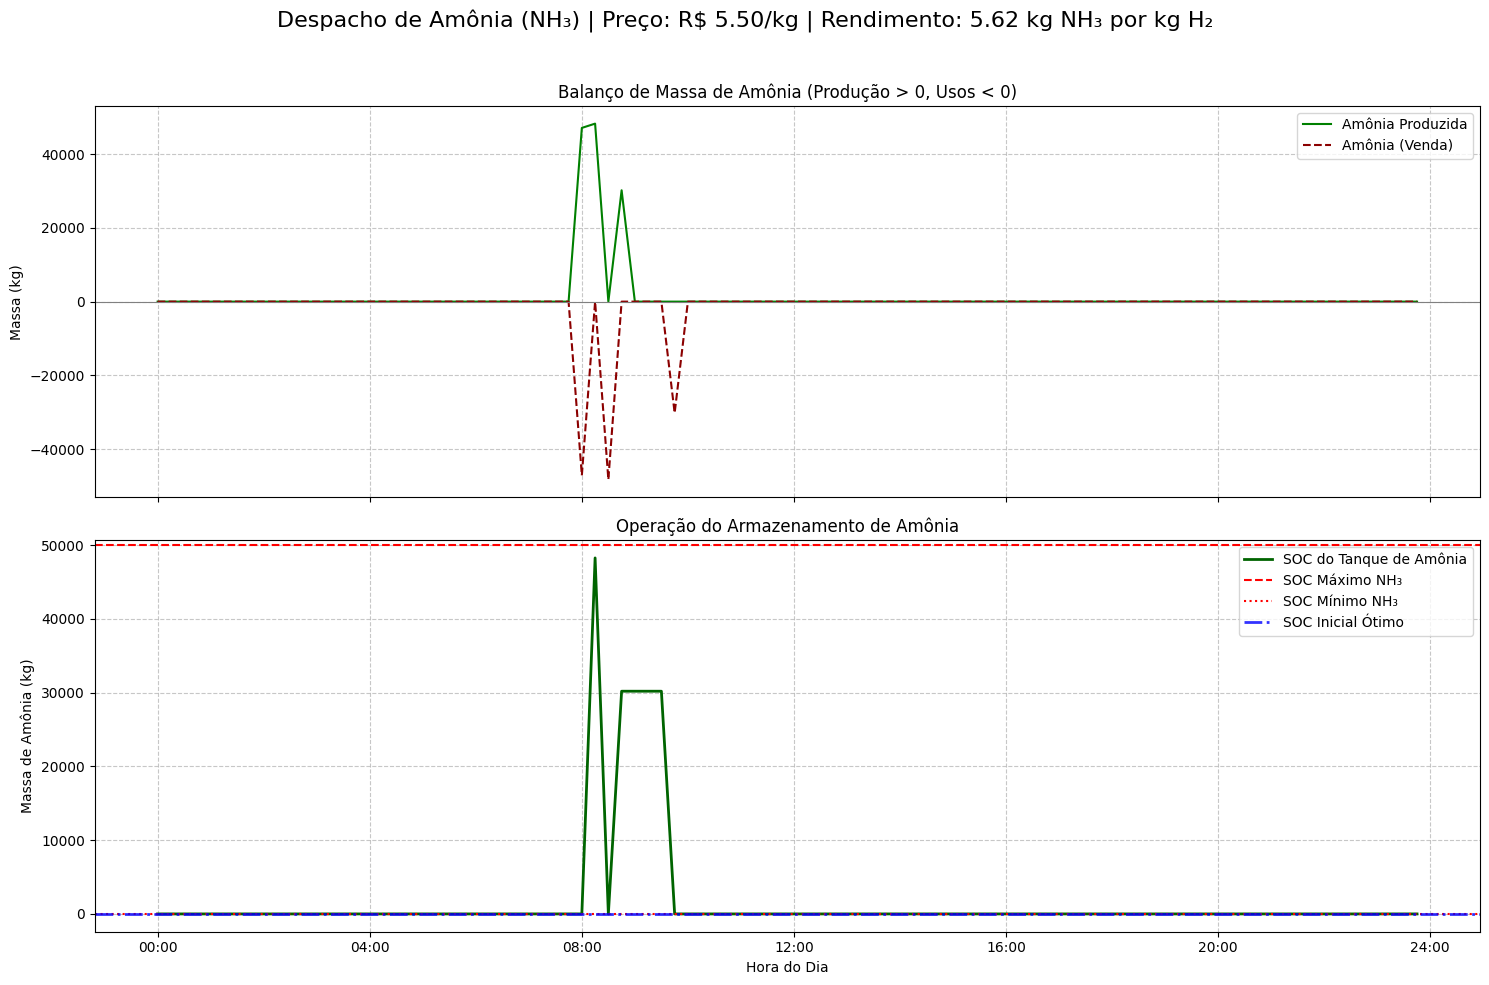

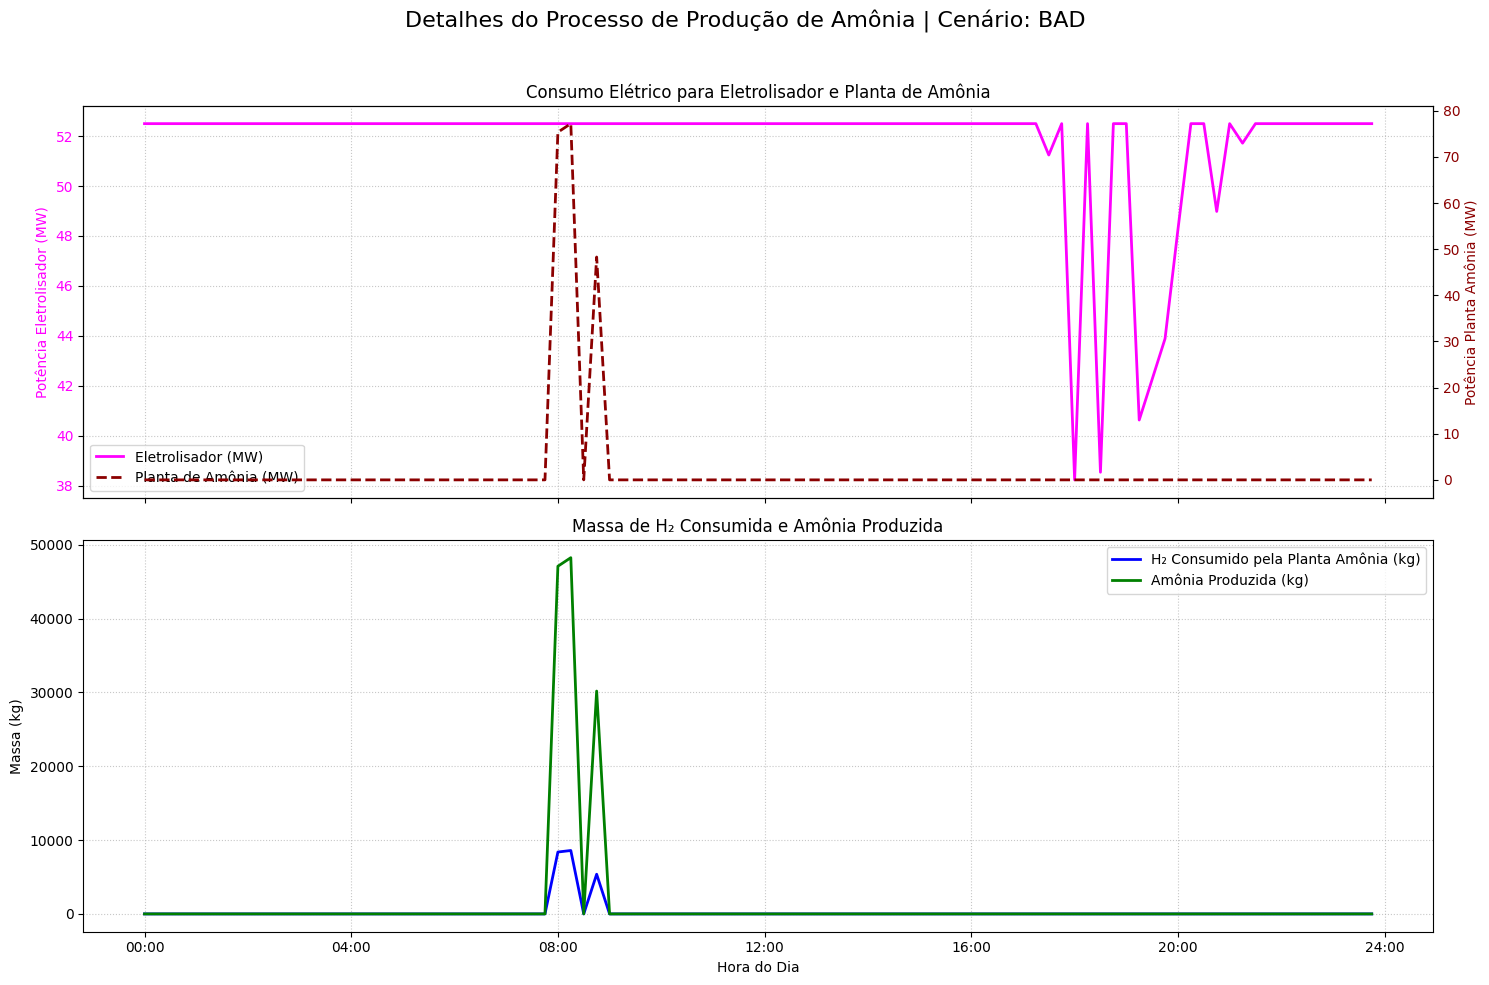

In [8]:
nome_do_arquivo_pld = '../market-data/PLD_NE_12_meses.xlsx'
nome_do_arquivo_solar = '../solar-data/solar_data.xlsx'
nome_do_arquivo_eolica = '../wind-data/wind_data.xlsx'

try:
    pasta_do_script = os.path.dirname(os.path.abspath(__file__))
except NameError:
    pasta_do_script = os.getcwd()

caminho_pld_12meses = os.path.join(pasta_do_script, nome_do_arquivo_pld)
caminho_solar_data = os.path.join(pasta_do_script, nome_do_arquivo_solar)
caminho_wind_data = os.path.join(pasta_do_script, nome_do_arquivo_eolica)

# --- Carregamento e processamento dos dados de PLD ---
pld_data_for_scenarios = None
try:
    df_pld_completo = carregar_pld_12m(caminho_pld_12meses)
    print(f"Arquivo '{nome_do_arquivo_pld}' carregado com sucesso. {len(df_pld_completo)} registros encontrados.")
    df_pld_completo['hour'] = df_pld_completo['data'].dt.hour
    pld_alto_horario = df_pld_completo.groupby('hour')['pld'].quantile(0.90).reindex(range(24)).ffill().to_numpy()
    pld_medio_horario = df_pld_completo.groupby('hour')['pld'].median().reindex(range(24)).ffill().to_numpy()
    pld_baixo_horario = df_pld_completo.groupby('hour')['pld'].quantile(0.10).reindex(range(24)).ffill().to_numpy()

    # Função auxiliar para interpolar PLD para 15min (já existia)
    def interpolar_pld_para_15min(pld_horario):
        horas_originais = np.arange(24)
        horas_alvo = np.arange(0, 24, INTERVALO_HORAS)
        return np.interp(horas_alvo, horas_originais, np.roll(pld_horario, 1))

    pld_data_for_scenarios = {
        'high': interpolar_pld_para_15min(pld_alto_horario).tolist(),
        'mean': interpolar_pld_para_15min(pld_medio_horario).tolist(),
        'low': interpolar_pld_para_15min(pld_baixo_horario).tolist()
    }
except (FileNotFoundError, ValueError) as e:
    print(f"\n*** ERRO CRÍTICO AO PROCESSAR O ARQUIVO DE PLD: {e} ***")
    print("A execução foi interrompida. Verifique o arquivo e o caminho.")
    exit() # Interrompe a execução se o PLD não puder ser carregado

# --- Carregamento e processamento dos dados reais de Geração Solar e Eólica ---
solar_mean_profile_aggregated = None
wind_mean_profile_aggregated = None

try:
   # print(f"\n--- Processando dados de Geração Solar Reais (Média Agregada) do arquivo '{nome_do_arquivo_solar}' ---")
    solar_mean_profile_aggregated = carregar_geracao_data(
        caminho_solar_data, N_intervals=N, unit_conversion_factor=1e6, sheet_name=0
    )
 #   print(f"Perfil Solar de Média Agregada: {len(solar_mean_profile_aggregated)} pontos.")
 #   print("Primeiros 10 valores do perfil solar agregado (Watts):", solar_mean_profile_aggregated[:10])
   #  print("Últimos 10 valores do perfil solar agregado (Watts):", solar_mean_profile_aggregated[-10:])
   #  print("Valor máximo no perfil solar agregado (Watts):", max(solar_mean_profile_aggregated))
   #  print("Valor mínimo no perfil solar agregado (Watts):", min(solar_mean_profile_aggregated))
except (FileNotFoundError, ValueError) as e:
   #  print(f"\n*** ERRO CRÍTICO AO PROCESSAR O ARQUIVO SOLAR: {e} ***")
   #  print("A execução foi interrompida. Verifique o arquivo e o caminho.")
    exit()

try:
   #  print(f"\n--- Processando dados de Geração Eólica Reais (Média Agregada) do arquivo '{nome_do_arquivo_eolica}' ---")
    wind_mean_profile_aggregated = carregar_geracao_data(
        caminho_wind_data, N_intervals=N, unit_conversion_factor=1e6, sheet_name=0
    )
   #  print(f"Perfil Eólico de Média Agregada: {len(wind_mean_profile_aggregated)} pontos.")
   #  print("Primeiros 10 valores do perfil eólico agregado (Watts):", wind_mean_profile_aggregated[:10])
   #  print("Últimos 10 valores do perfil eólico agregado (Watts):", wind_mean_profile_aggregated[-10:])
   #  print("Valor máximo no perfil eólico agregado (Watts):", max(wind_mean_profile_aggregated))
   #  print("Valor mínimo no perfil eólico agregado (Watts):", min(wind_mean_profile_aggregated))
except (FileNotFoundError, ValueError) as e:
   #  print(f"\n*** ERRO CRÍTICO AO PROCESSAR O ARQUIVO EÓLICO: {e} ***")
   #  print("A execução foi interrompida. Verifique o arquivo e o caminho.")
    exit()

h2_price_to_test = 30.00
ammonia_prices_to_test = [4.00, 5.50]

if pld_data_for_scenarios and solar_mean_profile_aggregated and wind_mean_profile_aggregated:
    for ammonia_price in ammonia_prices_to_test:
     #    print("\n" + "="*80)
     #    print(f"INICIANDO OTIMIZAÇÃO COM PREÇO AMÔNIA = R$ {ammonia_price:.2f}/kg (H₂ fixo em R$ {h2_price_to_test:.2f}/kg)")
      #   print("="*80 + "\n")

        # Passamos os perfis de média agregada para solar e eólica para a função
        all_scenario_profiles = load_and_process_scenario_data(
            pld_data=pld_data_for_scenarios,
            solar_mean_profile=solar_mean_profile_aggregated,
            wind_mean_profile=wind_mean_profile_aggregated,
            fixed_h2_price=h2_price_to_test,
            fixed_ammonia_price=ammonia_price
        )

      #   print("\nIniciando a resolução do Modelo Estocástico...")
        all_scenario_names = ["optimal", "good", "bad"]
        options = {"solver": "cplex"}

        creator_with_data = lambda scenario_name, **kwargs: scenario_creator(
            scenario_name, all_profiles=all_scenario_profiles, **kwargs
        )
        
        ef_builder = ExtensiveForm(options, all_scenario_names, creator_with_data)
        solver = pyo.SolverFactory(options["solver"])
        results = solver.solve(ef_builder.ef, tee=True)

        if results.solver.termination_condition in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal]:
         #    print(f"\n--- Resultados da Otimização ---")
            ef_model = ef_builder.ef
            
            expected_profit = pyo.value(ef_model.EF_Obj)
            print(f"Valor Objetivo Ótimo (Lucro Esperado Total): R$ {expected_profit:,.2f}")
            
            first_block = getattr(ef_model, all_scenario_names[0])
            initial_socs = {
                'elec': pyo.value(first_block.X['ELEC_INITIAL_SOC']),
                'h2': pyo.value(first_block.X['H2_INITIAL_SOC']),
                'ammonia': pyo.value(first_block.X['AMMONIA_INITIAL_SOC'])
            }
          #   print("\nDecisões do Primeiro Estágio (aqui e agora):")
          #   print(f"  SOC Inicial Ótimo da BESS: {initial_socs['elec'] / 1e6:.2f} MWh")
          #   print(f"  SOC Inicial Ótimo do Tanque de H2: {initial_socs['h2']:.2f} kg")
           #  print(f"  SOC Inicial Ótimo do Tanque de Amônia: {initial_socs['ammonia']:.2f} kg")
            
           #  print("\nParâmetros Econômicos e de Conversão da Simulação:")
           #  print("-" * 50)
           #  print(f"  - Preço de Venda do H₂:       R$ {h2_price_to_test:.2f}/kg")
           #  print(f"  - Preço de Venda da Amônia:   R$ {ammonia_price:.2f}/kg")
            rendimento_h2_nh3 = 1 / TX_H2_TO_AMMONIA_KG_PER_KG
           #  print(f"  - Fator Haber-Bosch (Inverso): {rendimento_h2_nh3:.2f} kg de NH₃ gerados por kg de H₂")
           #  print("-" * 50)

            for s_name in all_scenario_names:
                s_block = getattr(ef_model, s_name)
                plot_scenario_results(
                    s_block, s_name, initial_socs, 
                    fixed_h2_price=h2_price_to_test,
                    fixed_ammonia_price=ammonia_price
                )
        else:
            print(f"\nO solver não encontrou uma solução ótima. Condição de Término: {results.solver.termination_condition}")